# PROYECTO FINAL: INDIA

Primer dataset: Indian States Statistics: indicadores educativos por estados de India.

Segundo dataset: Ranking de las 100 Top instituciones o universidades de India (2020-2025).

Importacion de librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Carga de ficheros

In [2]:
# carga del dataset1: India_Education_Statistics.csv

df_Educ = pd.read_csv('../data/raw/India_Education_Statistics.csv')

In [3]:
df_Educ.head()

,Table Name,State Code,District Code,Tehsil Code,Area Name,Total/ Rural/ Urban,Age-group,Total - Persons,Total - Males,Total - Females,...,Educational level - Non-technical diploma or certificate not equal to degree - Females,Educational level - Technical diploma or certificate not equal to degree - Persons,Educational level - Technical diploma or certificate not equal to degree - Males,Educational level - Technical diploma or certificate not equal to degree - Females,Educational level - Graduate & above - Persons,Educational level - Graduate & above - Males,Educational level - Graduate & above - Females,Educational level - Unclassified - Persons,Educational level - Unclassified - Males,Educational level - Unclassified - Females
0,C2308,0,0,0,INDIA,Total,All ages,1028610328,532156772,496453556,...,127542,3666680,2900839,765841,37670147,25533308,12136839,97756,67969,29787
1,C2308,0,0,0,INDIA,Total,0-6,163819614,84999203,78820411,...,0,0,0,0,0,0,0,0,0,0
2,C2308,0,0,0,INDIA,Total,7,23045028,11910330,11134698,...,0,0,0,0,0,0,0,2743,1513,1230
3,C2308,0,0,0,INDIA,Total,8,31031074,16174274,14856800,...,0,0,0,0,0,0,0,2831,1567,1264
4,C2308,0,0,0,INDIA,Total,9,20868238,10770638,10097600,...,0,0,0,0,0,0,0,1454,841,613


In [4]:
# carga del dataset2: NIRF Rank (consta de 6 ficheros):
dfs = [
    pd.read_csv(f'../data/raw/NIRF Ranking {year}.csv')
    for year in range(2020, 2026)
]

In [5]:
# Verifico que los 6 ficheros (2020 - 2025) tienen la misma estructura idéntica
for year in range(2020, 2026):
    df = pd.read_csv(f'../data/raw/NIRF Ranking {year}.csv')
    print(year, df.shape, list(df.columns))

2020 (100, 11) ['Institute ID', 'Institute Name', 'TLR', 'RPC', 'GO', 'OI', 'PERCEPTION', 'City', 'State', 'Score', 'Rank']
2021 (100, 11) ['Institute ID', 'Institute Name', 'TLR', 'RPC', 'GO', 'OI', 'PERCEPTION', 'City', 'State', 'Score', 'Rank']
2022 (100, 11) ['Institute ID', 'Institute Name', 'TLR', 'RPC', 'GO', 'OI', 'PERCEPTION', 'City', 'State', 'Score', 'Rank']
2023 (100, 11) ['Institute ID', 'Institute Name', 'TLR', 'RPC', 'GO', 'OI', 'PERCEPTION', 'City', 'State', 'Score', 'Rank']
2024 (100, 28) ['Institute ID', 'Institute Name', 'TLR', 'RPC', 'GO', 'OI', 'PERCEPTION', 'City', 'State', 'Score', 'Rank', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27']
2025 (100, 11) ['Institute ID', 'Institute Name', 'TLR', 'RPC', 'GO', 'OI', 'PERCEPTION', 'City', 'State', 'Score', 'Rank']


In [ ]:
# Parece que los ficheros son idénticos salvo el fichero del 2024 que debe tener algunas columnas vacías.
# Las elimino porque no tiene sentido dejarlas al estar vacías sin valor

In [6]:
for año in range(2020, 2026):
    df = pd.read_csv(f'../data/raw/NIRF Ranking {año}.csv')
    
    # Elimino columnas sin nombre (vacías) tipo "Unnamed: X"
    df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
    
    print(año, df.shape, list(df.columns))

2020 (100, 11) ['Institute ID', 'Institute Name', 'TLR', 'RPC', 'GO', 'OI', 'PERCEPTION', 'City', 'State', 'Score', 'Rank']
2021 (100, 11) ['Institute ID', 'Institute Name', 'TLR', 'RPC', 'GO', 'OI', 'PERCEPTION', 'City', 'State', 'Score', 'Rank']
2022 (100, 11) ['Institute ID', 'Institute Name', 'TLR', 'RPC', 'GO', 'OI', 'PERCEPTION', 'City', 'State', 'Score', 'Rank']
2023 (100, 11) ['Institute ID', 'Institute Name', 'TLR', 'RPC', 'GO', 'OI', 'PERCEPTION', 'City', 'State', 'Score', 'Rank']
2024 (100, 11) ['Institute ID', 'Institute Name', 'TLR', 'RPC', 'GO', 'OI', 'PERCEPTION', 'City', 'State', 'Score', 'Rank']
2025 (100, 11) ['Institute ID', 'Institute Name', 'TLR', 'RPC', 'GO', 'OI', 'PERCEPTION', 'City', 'State', 'Score', 'Rank']


Ahora sí son todos los ficheros idénticos, con la misma estructura.
Lo práctico es fusionar los 6 ficheros en uno único, añadiendo previamente la columna "Año". 

La variable 'State' será la variable en común con el df_Educ que veremos después.

In [7]:
## Fusiono el fichero: Genero el df_Rank_final

dfs = []

for año in range(2020, 2026):
    df = pd.read_csv(f"../data/raw/NIRF Ranking {año}.csv")
    df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

    df["Año"] = año
    dfs.append(df)

df_Rank_final = pd.concat(dfs, ignore_index=True)

print(df_Rank_final.shape) # Debería ser (600, 12)
df_Rank_final.head()


(600, 12)


,Institute ID,Institute Name,TLR,RPC,GO,OI,PERCEPTION,City,State,Score,Rank,Año
0,IR-O-U-0456,Indian Institute of Technology Madras,85.61,92.51,86.32,63.57,97.13,Chennai,Tamil Nadu,86.76,1,2020
1,IR-O-U-0220,Indian Institute of Science,79.13,91.48,78.23,58.39,100.00,Bengaluru,Karnataka,82.67,2,2020
2,IR-O-U-0306,Indian Institute of Technology Bombay,83.52,87.81,80.86,57.48,91.96,Mumbai,Maharashtra,82.52,3,2020
3,IR-O-I-1074,Indian Institute of Technology Delhi,84.02,84.46,75.07,67.97,93.89,New Delhi,Delhi,81.75,4,2020
4,IR-O-I-1075,Indian Institute of Technology Kanpur,80.50,75.23,80.74,56.97,79.30,Kanpur,Uttar Pradesh,76.50,5,2020


In [8]:
df_Rank_final.tail() ## así veo que efectivamente el df contiene todos los años

,Institute ID,Institute Name,TLR,RPC,GO,OI,PERCEPTION,City,State,Score,Rank,Año
595,IR-O-U-0217,Christ University,56.19,28.34,65.44,74.23,37.84,Bengaluru,Karnataka,49.65,96,2025
596,IR-O-U-0055,National Institute of Technology Silchar,53.21,45.07,70.76,54.17,4.63,Silchar,Assam,49.51,97,2025
597,IR-O-U-0749,Manipal University Jaipur,63.48,33.80,64.04,66.76,7.11,Jaipur,Rajasthan,49.38,98,2025
598,IR-O-U-0739,Madan Mohan Malaviya University of Technology,67.91,18.82,70.37,71.73,18.48,Gorakhpur,Uttar Pradesh,49.11,99,2025
599,IR-O-U-0688,All India Institute of Medical Sciences Bhuban...,69.14,25.45,58.25,69.89,20.28,Khordha,Odisha,49.04,100,2025


# Análisis preliminar del dataset: df_Educ (Indian_Education_Statistics)

In [9]:
## Compruebo estructura, características, columnas, tipos de variables, etc

df_Educ.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3132 entries, 0 to 3131
Data columns (total 46 columns):
 #   Column                                                                                       Non-Null Count  Dtype 
---  ------                                                                                       --------------  ----- 
 0   Table Name                                                                                   3132 non-null   object
 1   State Code                                                                                   3132 non-null   int64 
 2   District Code                                                                                3132 non-null   int64 
 3   Tehsil Code                                                                                  3132 non-null   int64 
 4   Area Name                                                                                    3132 non-null   object
 5   Total/ Rural/ Urban                      

El tipo de las variables son correctas, no tengo que modificar ninguna. Son de tipo object o numéricas (entero).

## Descripción de las variables del df_Educ (India_Education_Statistics)

Este conjunto de datos recoge información del nivel educativo de la población de toda la India, probablemente corresponde al censo del 2011 (último medido). La edad registrada comienza desde los 7 años hasta edades más longevas.

Según el Censo, una persona de siete años o más que sabe leer y escribir con comprensión en cualquier idioma se considera alfabetizada. Una persona que solo sabe leer pero no escribir se considera analfabeta. 

Los datos proporcionan detalles sobre el código estatal, el código de distrito, el nombre del área, el grupo de edad, alfabetizados, analfabetos, alfabetizados sin nivel educativo, inferior a primaria, primaria, secundaria, bachillerato/secundaria, secundaria superior/intermedia, preuniversitario/secundaria superior, diploma o certificado no técnico (no equivalente a título), diploma o certificado técnico (no equivalente a título), posgrado y superior, y nivel educativo no clasificado.

Cada fila del dataset corresponde a una unidad administrativa o censal con una edad determinada. Esto significa que no hay una fila única por estado.

La jeraquía administrativa india es: Estado → Distrito → Tehsil → Pueblo/Ciudad

VARIABLES:

Table Name: solo presenta el valor C2308. 

State Code: indica el código del estado.

District Code: indica el código del distrito

Tehsil Code: indica el código Tehsil, similar al código postal que conocemos. 

Area Name: indica el nombre del estado.

Total/ Rural/ Urban: indica si la zona del estado es Rural, Urban o Total.

Age-group: indica la edad.

Total - Persons: indica el total de personas en la unidad admninistrativa.

Total - Males: indica el total de hombres en la unidad administrativa.

Total - Females: indica el total de mujeres en la unidad administrativa.

Illiterate - Persons: indica el numero de personas totales analfabetas, por unidad admva.

Illiterate - Males: indica el numero de hombres analfabetos por unidad admva.

Illiterate - Females: indica el numero de mujeres analfabetas por unidad admva.

Literate - Persons: indica el total de personas alfabetizadas, por unidad admva.

Literate - Males: indica el total de hombres alfabetizados, por unidad admva.

Literate - Females: indica el numero total de mujeres alfabetizadas, por unidad admva.

Educational level - Literate without educational level - Persons: indica el total de personas alfabetizadas sin nivel educativo por unidad admva.

Educational level - Literate without educational level - Males: indica el total de hombres alfabetizados sin nivel educativo por unidad admva.

Educational level - Literate without educational level - Females: indica el total de mujeres alfabetizadas sin nivel educativo por unidad admva.

Educational level - Below primary - Persons: indica el total de personas que no han completado la educación primaria por unidad admva.

Educational level - Below primary - Males: indica el total de hombres que no han completado la educación primaria por unidad admva.

Educational level - Below primary - Females: indica el total de mujeres que no han completado la educación primaria por unidad admva.

Educational level - Primary - Persons: indica el total de personas con educación primaria o básica por unidad admva. 

Educational level - Primary - Males: indica el total de hombres con educación primaria o básica por unidad admva.

Educational level - Primary - Females: indica el total de mujeres con educación primaria o básica por unidad admva.

Educational level - Middle - Persons: indica el total de personas con educacion secundaria básica por unidad admva.

Educational level - Middle - Males: indica el  total de hombres con educación secundaria básica por unidad admva.

Educational level - Middle - Females: indica el total de mujeres con educación secundaria básica por unidad admva.

Educational level - Matric/Secondary - Persons: indica el total de personas con educación secundaria completa por unidad admva.

Educational level - Matric/Secondary - Males: indica el total de hombres con educación secundaria completa por unidad admva.

Educational level - Matric/Secondary - Females: indica el total de mujeres con educación secundaria commpleta por unidad admva.

Educational level - Higher secondary/Intermediate/Pre-University/Senior secondary - Persons: indica el total de personas con estudios preuniversitarios, o de bachillerato por unidad admva.

Educational level - Higher secondary/Intermediate/Pre-University/Senior secondary - Males: indica el total de hombres con estudios preuniversitarios, o de bachillerato por unidad admva.

Educational level - Higher secondary/Intermediate/Pre-University/Senior secondary - Females: indica el total de mujeres con estudios preuniversitarios, o de bachillerato por unidad admva.

Educational level - Non-technical diploma or certificate not equal to degree - Persons: indica el total de personas con estudios posteriores a secundaria pero no universitarios por unidad admva.

Educational level - Non-technical diploma or certificate not equal to degree - Males: indica el total de hombres con estudios posteriores a secundaria pero no universitarios por unidad admva.

Educational level - Non-technical diploma or certificate not equal to degree - Females: indica el total de mujeres con estudios posteriores a secundaria pero no universitarios por unidad admva.

Educational level - Technical diploma or certificate not equal to degree - Persons: indica el total de personas con diploma técnico o certificado que no equivale a un título universitario por unidad admva. 

Educational level - Technical diploma or certificate not equal to degree - Males: indica el total de hombres con diploma técnico o certificado que no equivale a un título universitario por unidad admva. 

Educational level - Technical diploma or certificate not equal to degree - Females: indica el total de mujeres con diploma técnico o certificado que no equivale a un título universitario por unidad admva. 

Educational level - Graduate & above - Persons: indica el total de personas con título universitario completo por unidad admva.

Educational level - Graduate & above - Males: indica el total de hombres con título universitario completo por unidad admva.

Educational level - Graduate & above - Females: indica el total de mujeres con título universitario completo por unidad admva.

Educational level - Unclassified - Persons: indica el total de personas totales no clasificadas por unidad admva.

Educational level - Unclassified - Males: indica el total de hombres no clasificados por unidad admva.

Educational level - Unclassified - Females: indica el total de mujeres no clasificadas por unidad admva.


In [10]:
## Veo si hay duplicados y compruebo que no hay duplicados

df_Educ.duplicated().sum()

np.int64(0)

In [11]:
## Veo valores nulos (vacíos) y compruebo que no hay.
# 1º en el fichero df_Educ:
df_Educ.isna().sum().sort_values(ascending=False)

Table Name                                                                                     0
State Code                                                                                     0
District Code                                                                                  0
Tehsil Code                                                                                    0
Area Name                                                                                      0
Total/ Rural/ Urban                                                                            0
Age-group                                                                                      0
Total - Persons                                                                                0
Total - Males                                                                                  0
Total - Females                                                                                0
Illiterate - Persons          

In [12]:
## veo los valores únicos de cada una de las variables. Esta variable se puede eliminar después porque no aporta información relevante.
df_Educ['Table Name'].unique()

array(['C2308'], dtype=object)

In [13]:
## Esta variable se puede eliminar después porque no aporta información relevante.
df_Educ['State Code'].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35])

In [14]:
## Esta variable se puede eliminar después porque no aporta información relevante.
df_Educ['District Code'].unique()  

array([0])

In [15]:
## Esta variable se puede eliminar después porque no aporta información relevante.
df_Educ['Tehsil Code'].unique()  

array([0])

In [16]:
## Esta variable que indica el estado es la que necesitaré después para unirla con el otro df
df_Educ['Area Name'].unique()

array(['INDIA', 'State - JAMMU & KASHMIR  01',
       'State - HIMACHAL PRADESH  02', 'State - PUNJAB  03',
       'State - CHANDIGARH  04', 'State - UTTARANCHAL  05',
       'State - HARYANA  06', 'State - DELHI  07',
       'State - RAJASTHAN  08', 'State - UTTAR PRADESH  09',
       'State - BIHAR  10', 'State - SIKKIM  11',
       'State - ARUNACHAL PRADESH  12', 'State - NAGALAND  13',
       'State - MANIPUR  14', 'State - MIZORAM  15',
       'State - TRIPURA  16', 'State - MEGHALAYA  17',
       'State - ASSAM  18', 'State - WEST BENGAL  19',
       'State - JHARKHAND  20', 'State - ORISSA  21',
       'State - CHHATTISGARH  22', 'State - MADHYA PRADESH  23',
       'State - GUJARAT  24', 'State - DAMAN & DIU  25',
       'State - DADRA & NAGAR HAVELI  26', 'State - MAHARASHTRA  27',
       'State - ANDHRA PRADESH  28', 'State - KARNATAKA  29',
       'State - GOA  30', 'State - LAKSHADWEEP  31', 'State - KERALA  32',
       'State - TAMIL NADU  33', 'State - PONDICHERRY  34',


La variable "Area Name" la tengo que normalizar para obtener solo el nombre del Estado, que será la variable común con el df del Ranking Top Universidades. Además, veo que contiene el estado "INDIA" que seguramente englobe a todos los estados.

In [17]:
df_Educ['Total/ Rural/ Urban'].unique()

array(['Total', 'Rural', 'Urban'], dtype=object)

In [18]:
df_Educ['Age-group'].unique()

array(['All ages', '0-6', '7', '8', '9', '10', '11', '12', '13', '14',
       '15', '16', '17', '18', '19', '20-24', '25-29', '30-34', '35-39',
       '40-44', '45-49', '50-54', '55-59', '60-64', '65-69', '70-74',
       '75-79', '80+', 'Age not stated'], dtype=object)

In [19]:
## La variable "Age-group" presenta diferentes edades en números aislados pero también en rangos o en texto. Tengo que convertir todo a una edad numérica
# aproximada.
## El valor "All ages" parece que es un total agregado, no aporta información nueva. Ya que la suma de personas totales con esta connotacion "All ages" es igual a 
## la suma de personas sin esta connotación (aquí sí incluye las personas no clasificadas con una edad determinada: "Age not stated")
## Por tanto, puedo eliminar estas filas de "All ages". Y renombraré el valor "Age not stated" por "Unknown"

## La suma de "All ages" es igual a la suma de todos los grupos de edad (sin "All ages")

## Voy a demostrarlo; creo dos subconjuntos,  uno solo con "All ages" y otro sin "All ages":

df_all = df_Educ[df_Educ['Age-group'] == 'All ages']
df_sin_all = df_Educ[df_Educ['Age-group'] != 'All ages']

## Vamos a comparar por ejemplo "Total - Persons":

suma_all = df_all['Total - Persons'].sum()
suma_sin_all = df_sin_all['Total - Persons'].sum()

print("Suma All ages:", suma_all)
print("Suma resto edades:", suma_sin_all)

Suma All ages: 4114441312
Suma resto edades: 4114441312


In [20]:
# Suma por Area Name y Age-group
tabla = df_Educ.groupby(['Area Name','Age-group'])['Total - Persons'].sum().reset_index()

# Separamos
all_ages = tabla[tabla['Age-group'] == 'All ages']
resto = tabla[tabla['Age-group'] != 'All ages']

# Sumamos el resto por Area Name
resto_sum = resto.groupby('Area Name')['Total - Persons'].sum().reset_index()

# Unimos para comparar
comparacion = all_ages.merge(resto_sum, on='Area Name', suffixes=('_All','_Resto'))

# Vemos si son iguales
comparacion['Coinciden'] = comparacion['Total - Persons_All'] == comparacion['Total - Persons_Resto']

comparacion.head()

,Area Name,Age-group,Total - Persons_All,Total - Persons_Resto,Coinciden
0,INDIA,All ages,2057220656,2057220656,True
1,State - ANDAMAN & NICOBAR ISLANDS 35,All ages,712304,712304,True
2,State - ANDHRA PRADESH 28,All ages,152420014,152420014,True
3,State - ARUNACHAL PRADESH 12,All ages,2195936,2195936,True
4,State - ASSAM 18,All ages,53311056,53311056,True


Con esto se verifica que la suma de los distintos grupos de edad coincide exactamente con 
el valor reportado en la categoría "All ages" para cada unidad geográfica. 
Por tanto, se decide eliminar dichas filas para evitar duplicación de información en el análisis.

In [21]:
## Elimino las filas de "All ages" aunque lo suyo sería hacerlo en la parte de Limpieza:

df_Educ = df_Educ[df_Educ['Age-group'] != 'All ages']

## Se eliminaron las filas correspondientes a "All ages" por representar el total agregado de todos los grupos de edad.
#  Dado que la suma de los distintos rangos coincide con ese total,
#  mantener dichas filas produciría duplicación de información en el análisis.
## Sin embargo, se conservan los registros de "Age not stated", luego lo renombraré como "Unknown", 
## ya que forman parte del total poblacional y pueden aportar información relevante sobre la calidad del dato.

In [22]:
df_Educ['Age-group'].unique()

array(['0-6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16',
       '17', '18', '19', '20-24', '25-29', '30-34', '35-39', '40-44',
       '45-49', '50-54', '55-59', '60-64', '65-69', '70-74', '75-79',
       '80+', 'Age not stated'], dtype=object)

In [23]:
## valores únicos por variable
df_Educ.nunique().sort_values()

Table Name                                                                                        1
District Code                                                                                     1
Tehsil Code                                                                                       1
Total/ Rural/ Urban                                                                               3
Age-group                                                                                        28
State Code                                                                                       36
Area Name                                                                                        36
Educational level - Unclassified - Females                                                      275
Educational level - Unclassified - Males                                                        397
Educational level - Non-technical diploma or certificate not equal to degree - Females          437


Estadísticas básicas de las variables numéricas. 

In [24]:
df_Educ.describe(include='number').T.round(2)

,count,mean,std,min,25%,50%,75%,max
State Code,3024.0,17.50,10.39,0.0,8.75,17.5,26.25,35.0
District Code,3024.0,0.00,0.00,0.0,0.00,0.0,0.00,0.0
Tehsil Code,3024.0,0.00,0.00,0.0,0.00,0.0,0.00,0.0
Total - Persons,3024.0,1360595.67,6127769.79,18.0,16872.00,158457.5,809102.75,163819614.0
Total - Males,3024.0,703911.07,3159944.84,12.0,9052.50,82182.5,418892.00,84999203.0
Total - Females,3024.0,656684.60,2969920.51,6.0,7790.00,75158.5,389937.75,78820411.0
Illiterate - Persons,3024.0,618945.15,4356038.90,3.0,3798.25,35814.0,237918.75,163819614.0
Illiterate - Males,3024.0,258760.66,2153205.54,0.0,1459.75,13910.0,85491.50,84999203.0
Illiterate - Females,3024.0,360184.49,2240264.20,2.0,2272.25,21196.5,148500.75,78820411.0
Literate - Persons,3024.0,741650.53,3051262.76,0.0,9872.00,84709.5,486209.50,65731454.0


In [25]:
# agrupo las variables numéricas en columnas_num
columnas_num = df_Educ.select_dtypes(include='number').columns

In [26]:
columnas_num

Index(['State Code', 'District Code', 'Tehsil Code', 'Total - Persons',
       'Total - Males', 'Total - Females', 'Illiterate - Persons',
       'Illiterate - Males', 'Illiterate - Females', 'Literate - Persons',
       'Literate - Males', 'Literate - Females',
       'Educational level - Literate without educational level - Persons',
       'Educational level - Literate without educational level - Males',
       'Educational level - Literate without educational level - Females',
       'Educational level - Below primary - Persons',
       'Educational level - Below primary - Males',
       'Educational level - Below primary - Females',
       'Educational level - Primary - Persons',
       'Educational level - Primary - Males',
       'Educational level - Primary - Females',
       'Educational level - Middle - Persons',
       'Educational level - Middle - Males',
       'Educational level - Middle - Females',
       'Educational level - Matric/Secondary - Persons',
       'Educatio

# Conclusiones tras el análisis estadístico básico

El fichero consta de 3.024 observaciones en todas las variables.

Estas tres primeras variables no aportan valor estadístico:

State Code: Código del estado. No se considera variable cuantitativa para el análisis estadístico.

District Code: Código del distrito. No se considera variable cuantitativa para el análisis estadístico.

Tehsil Code: Código Tehsil. No se considera variable cuantitativa para el análisis estadístico.

En cuanto al resto de variables numéricas, podemos decir lo siguiente:

Población total: El número medio de personas se sitúa en 1.360.595. La mediana, es decir, el 50% de la población es de 158.457 personas.
La media es muchísimo mayor que la mediana. Esto indica una distribución muy sesgada a la derecha.
Hay algunos distritos extremadamente grandes que elevan el promedio poblacional.
Diferenciando la población total por género, hay una ligera mayoría de hombres frente a mujeres. La diferencia no es muy extrema. De media, hay un total de 703.911 hombres frente a 656.684 mujeres.

Esta misma proporción se cumple en el resto de variables que cuantifican el nivel educativo de la población india.

En cuanto a la alfabetización de la población, estas estadísticas indican que, en promedio, hay más personas alfabetizadas que analfabetas.
Pero la dispersión sigue siendo muy alta, ya que la media es mayor que la mediana. Esto indica la presencia de valores extremos.

Sin incidir más en estos datos, podemos resumirlos en varias conclusiones que iremos demostrando a lo largo de este infome:

Alta variabilidad.
Distribuciones muy sesgadas.
Presencia fuerte de outliers.
La mediana es más representativa que la media.

# Histogramas de las variables numéricas

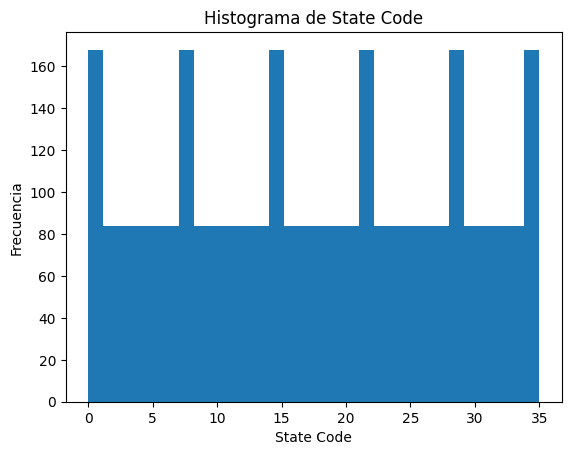

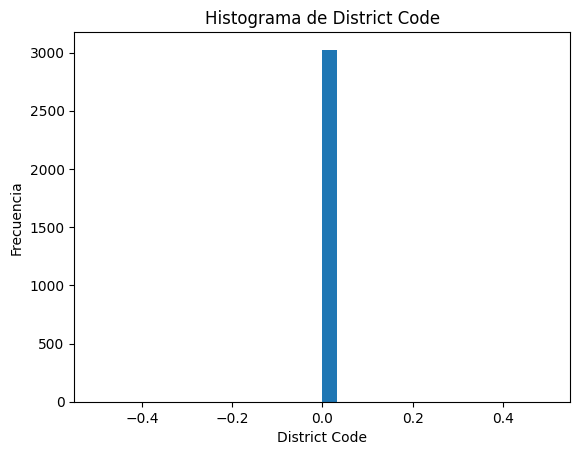

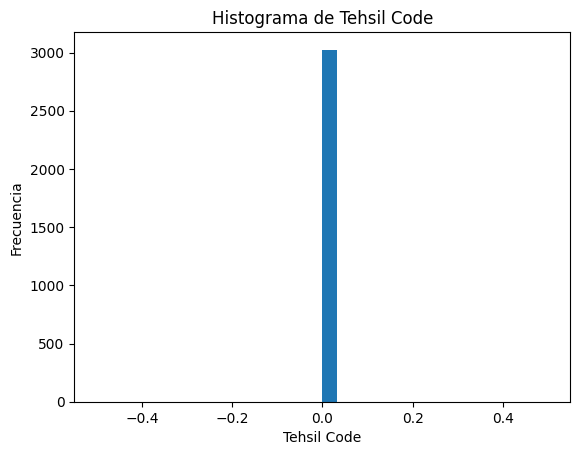

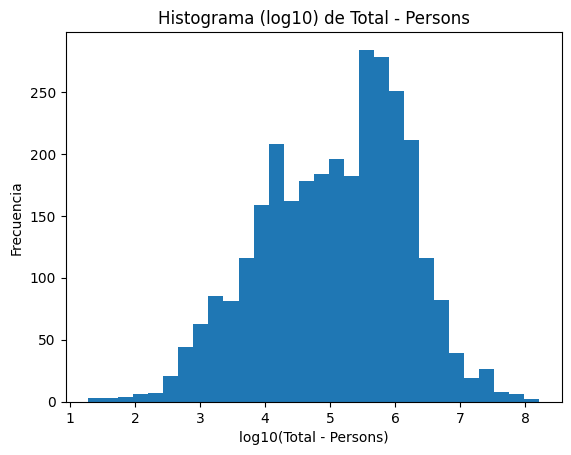

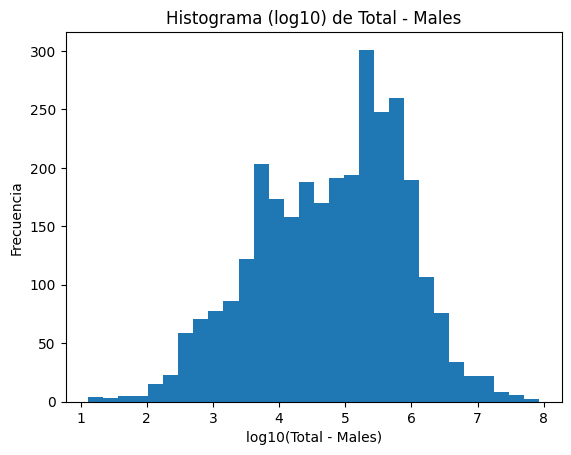

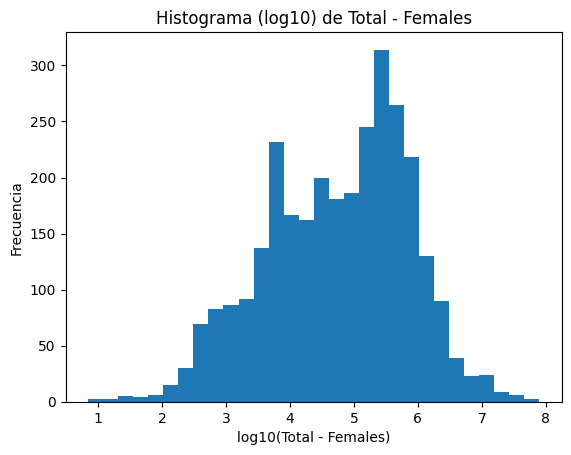

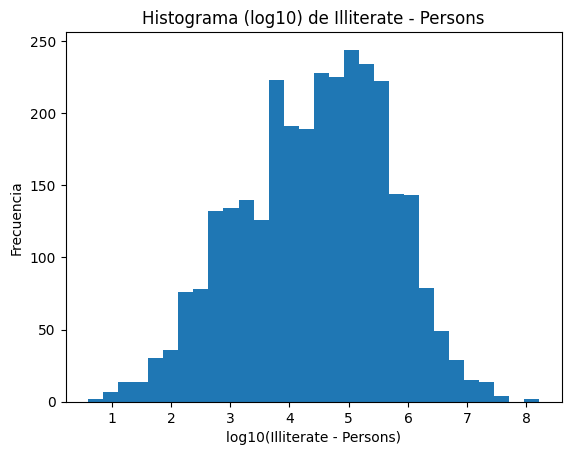

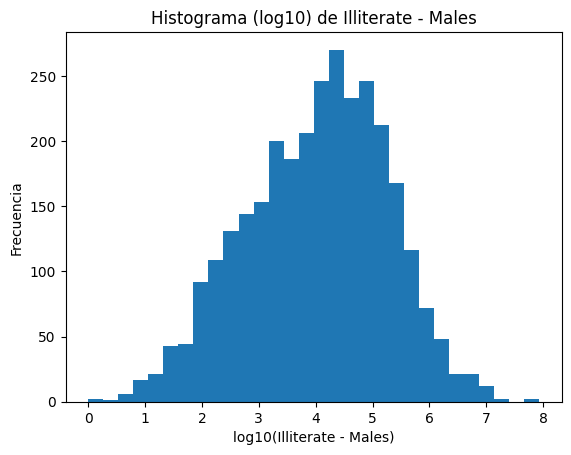

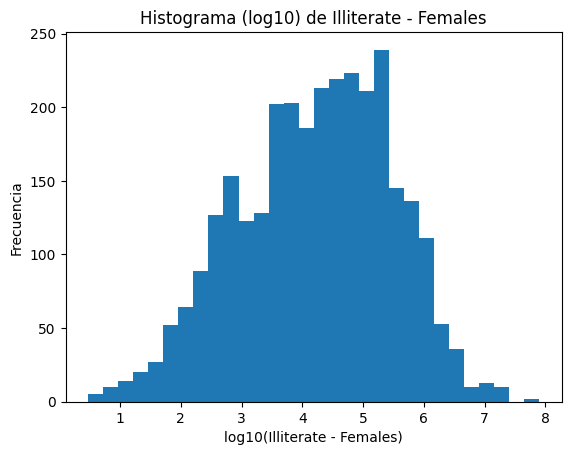

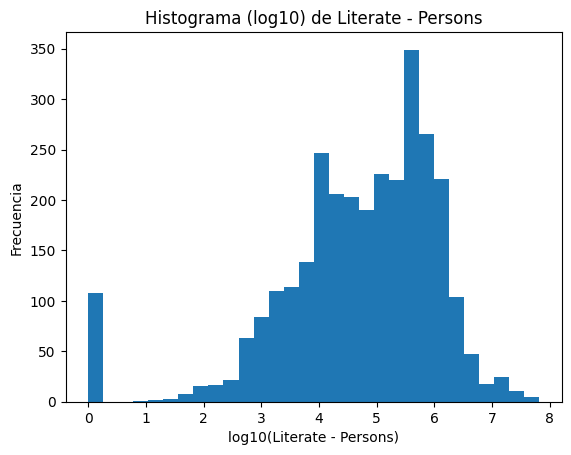

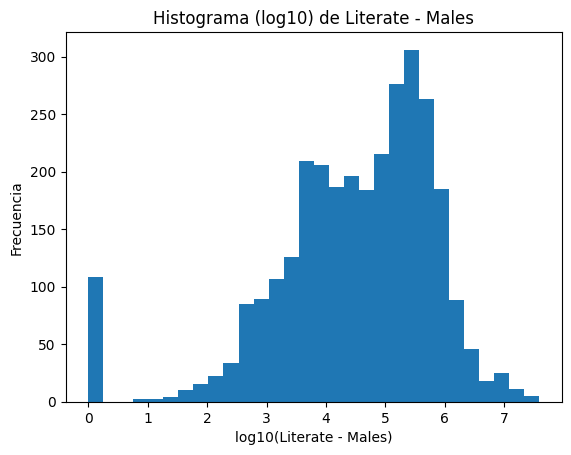

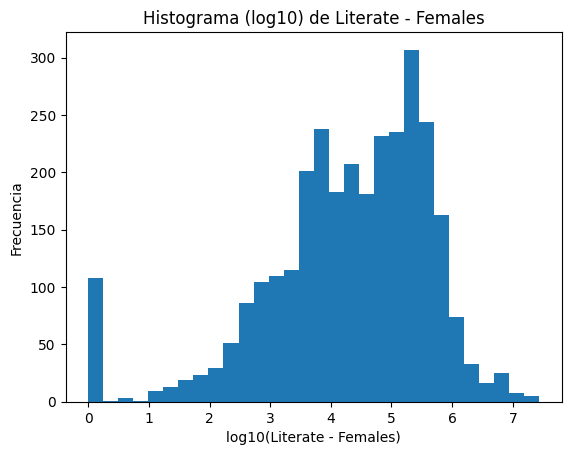

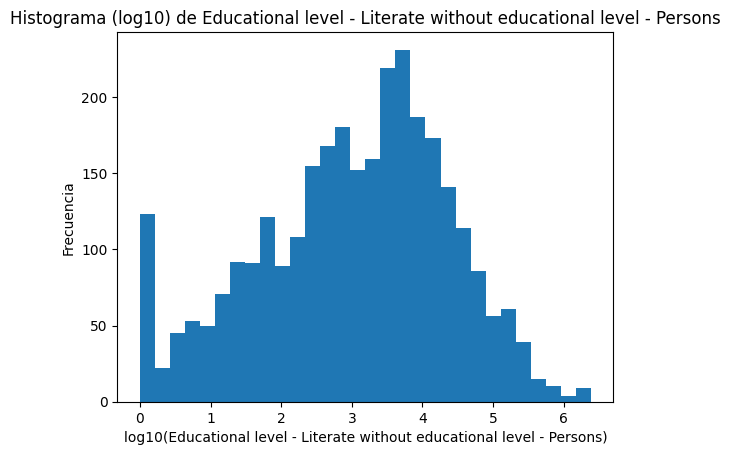

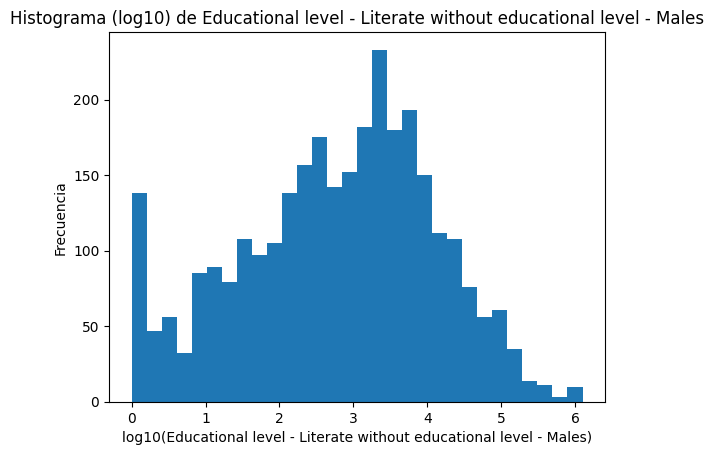

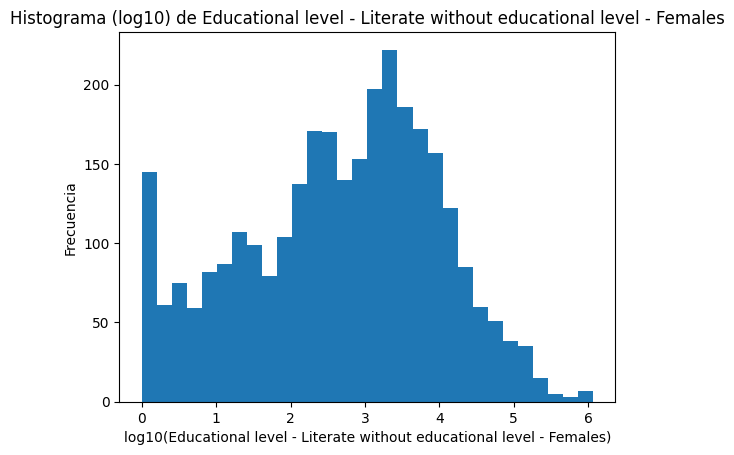

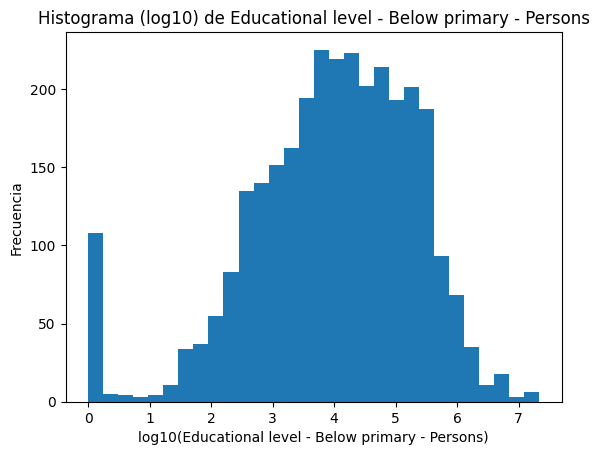

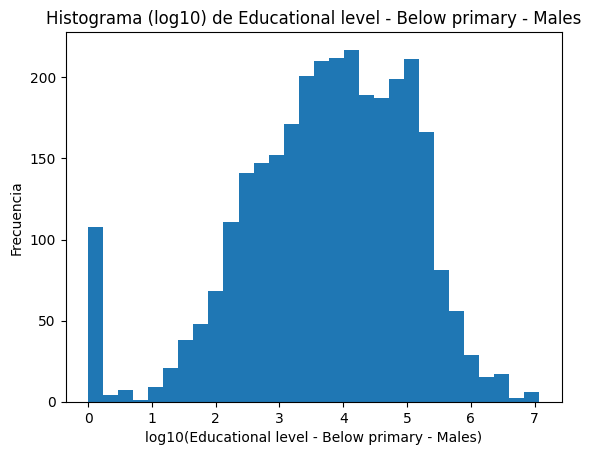

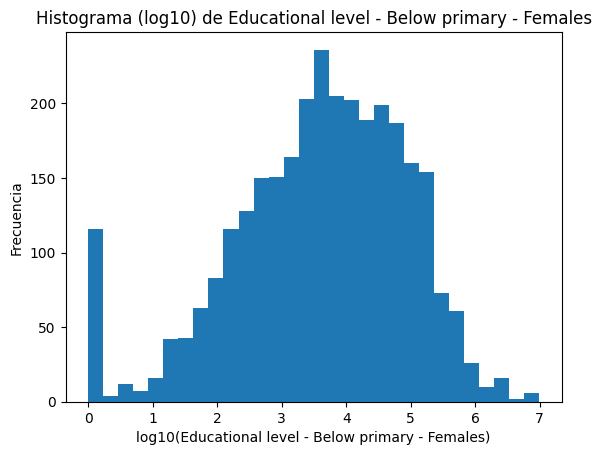

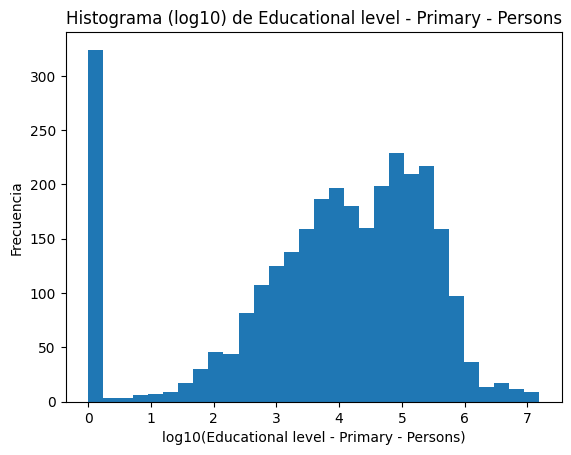

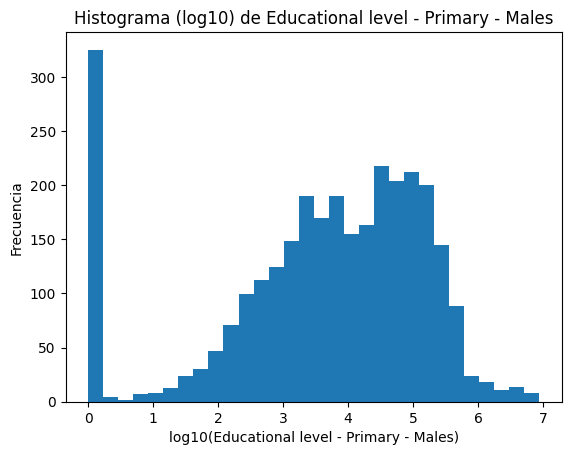

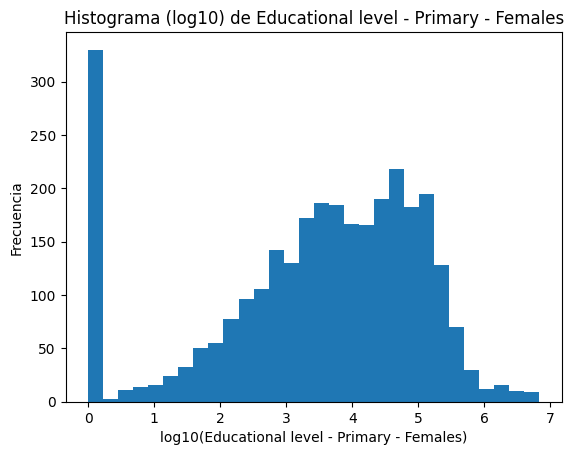

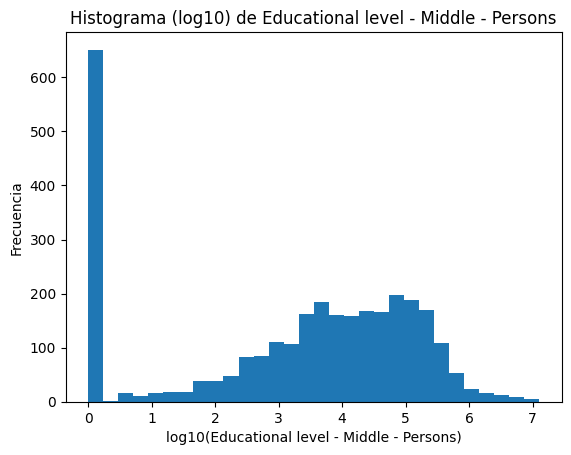

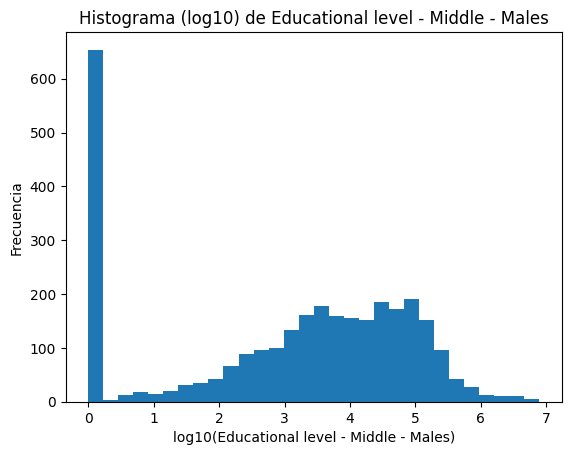

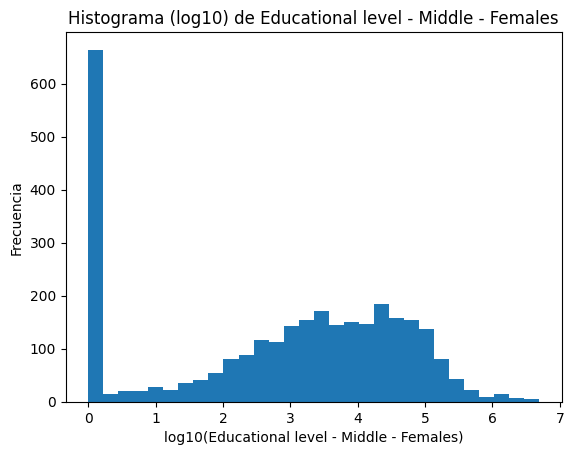

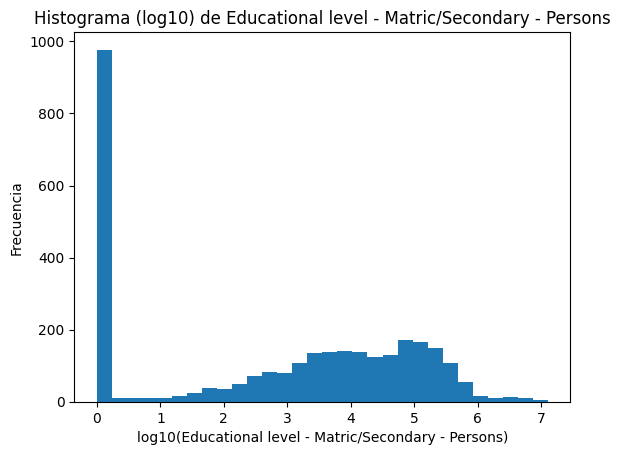

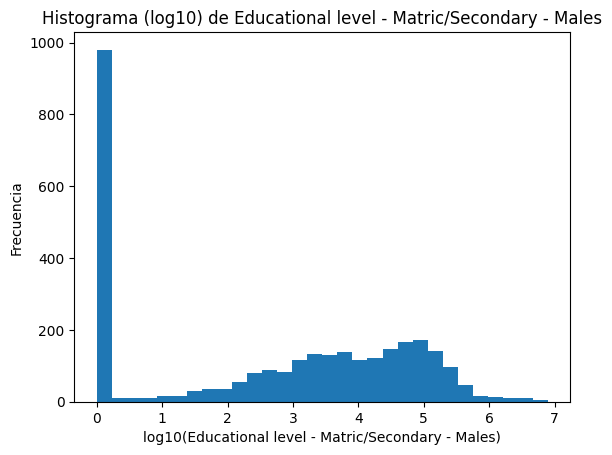

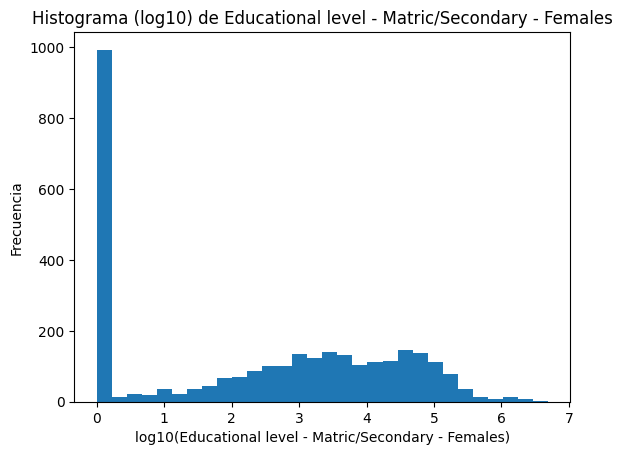

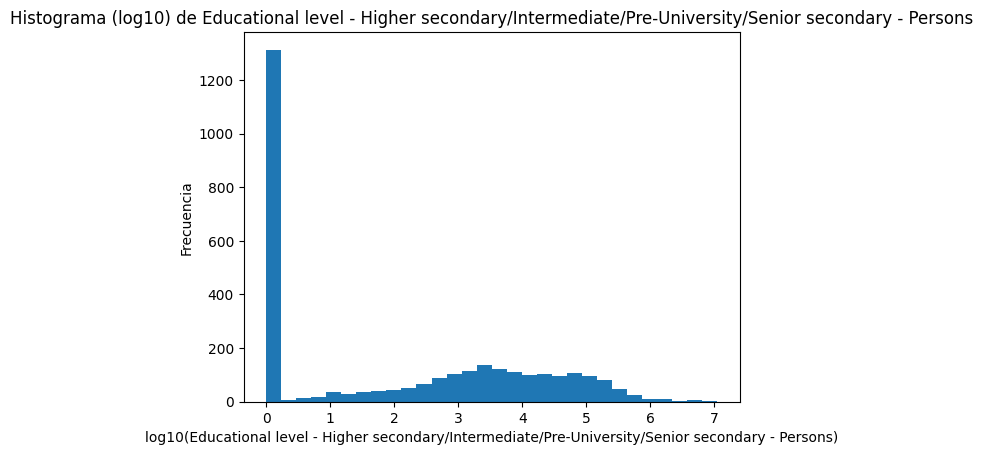

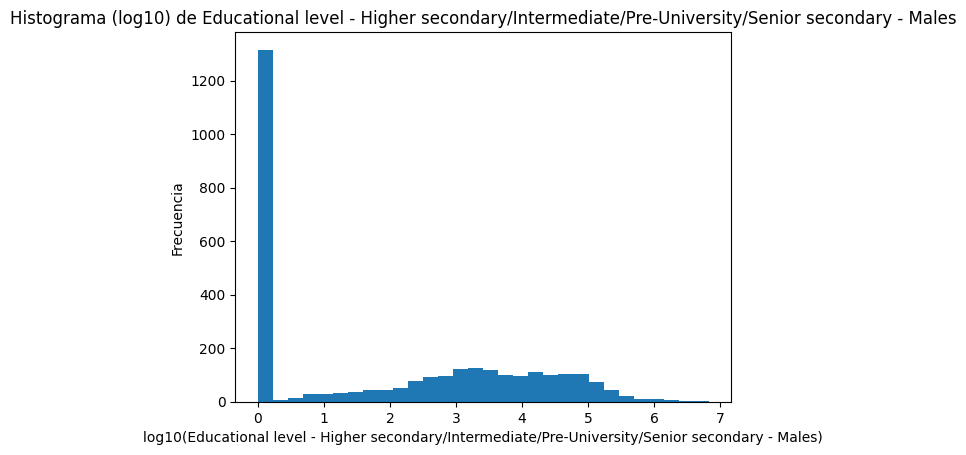

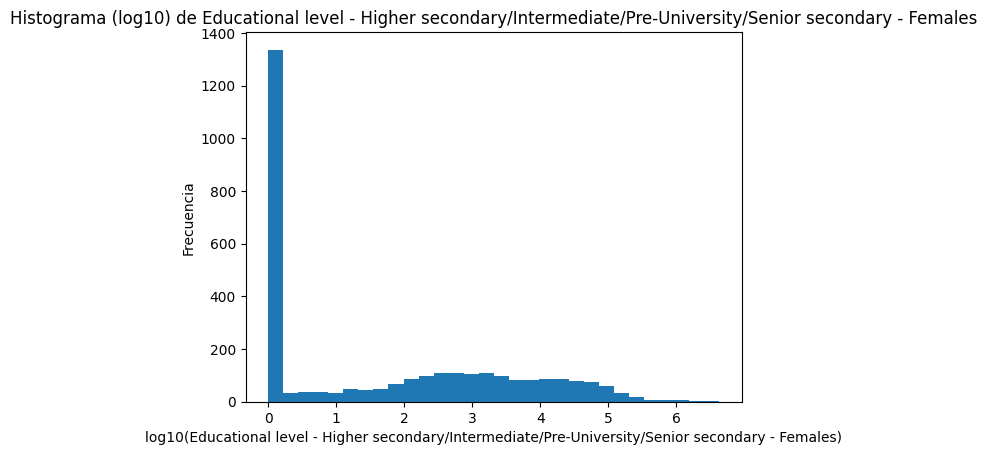

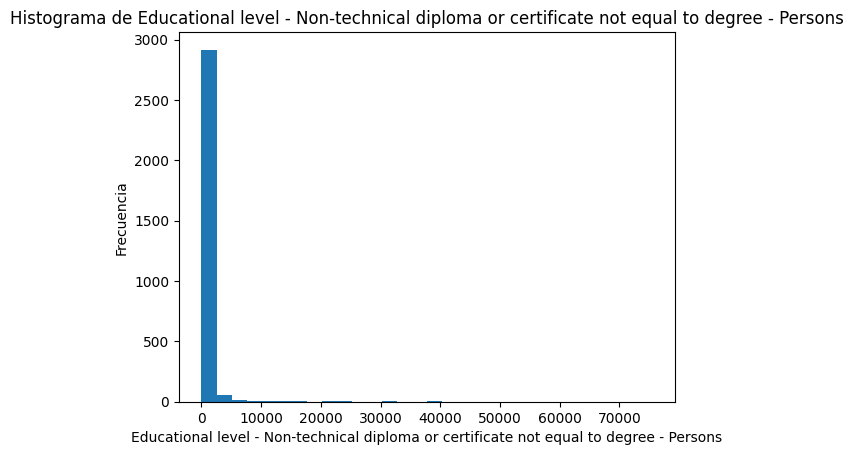

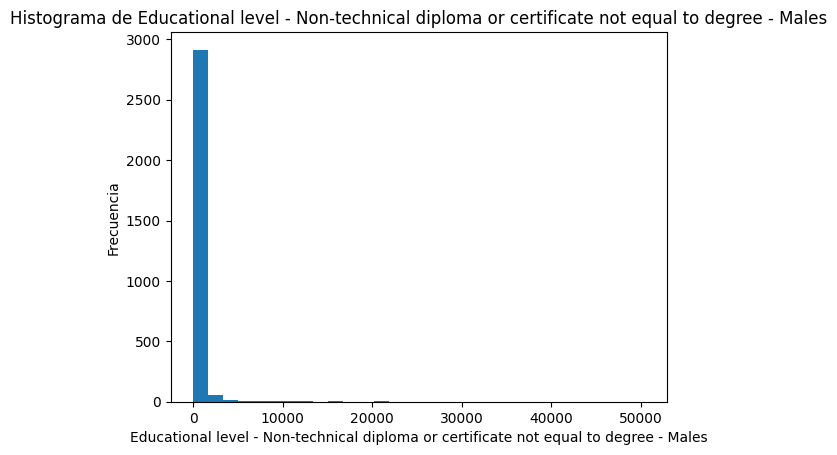

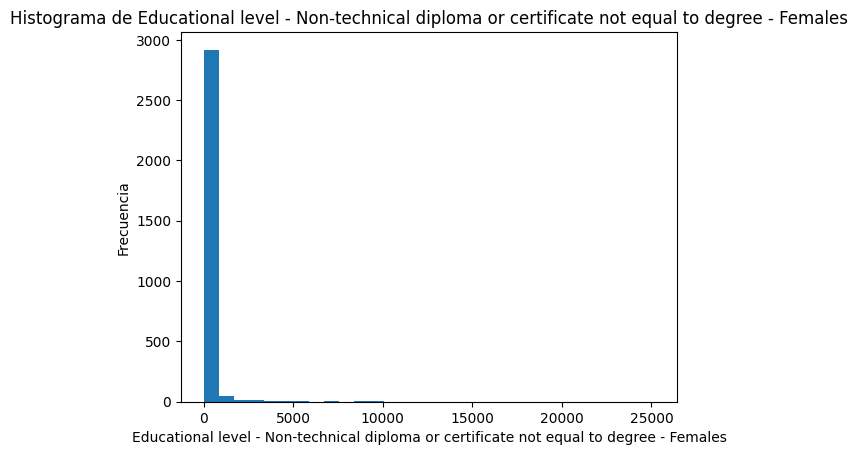

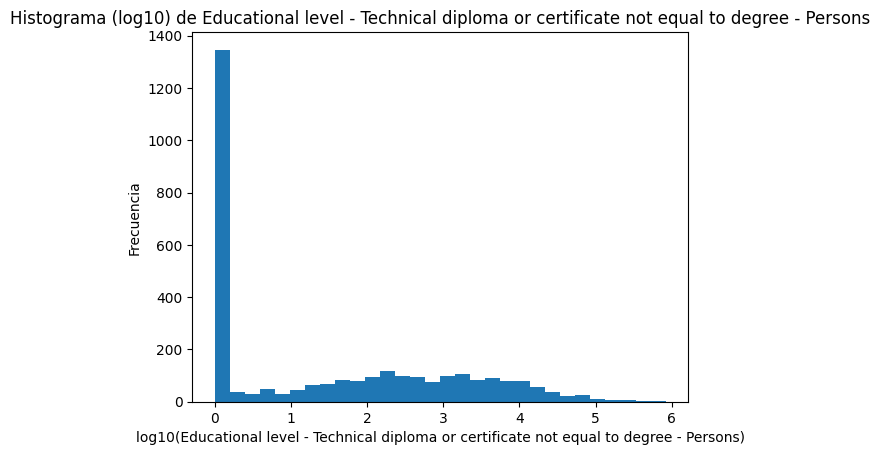

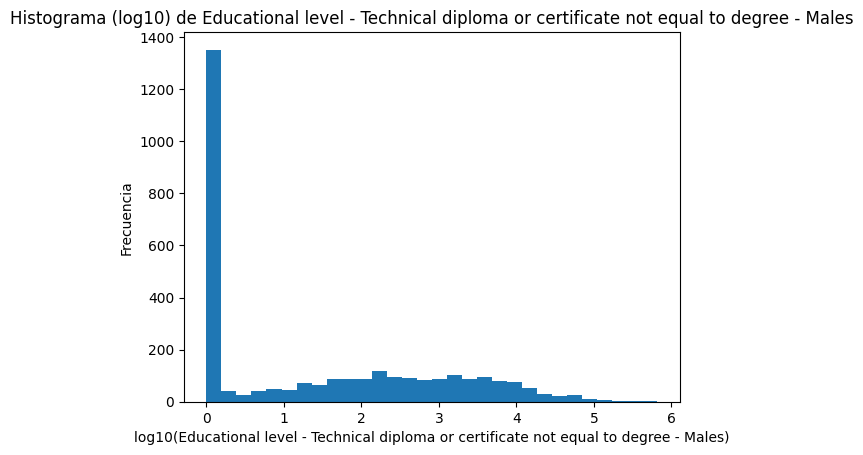

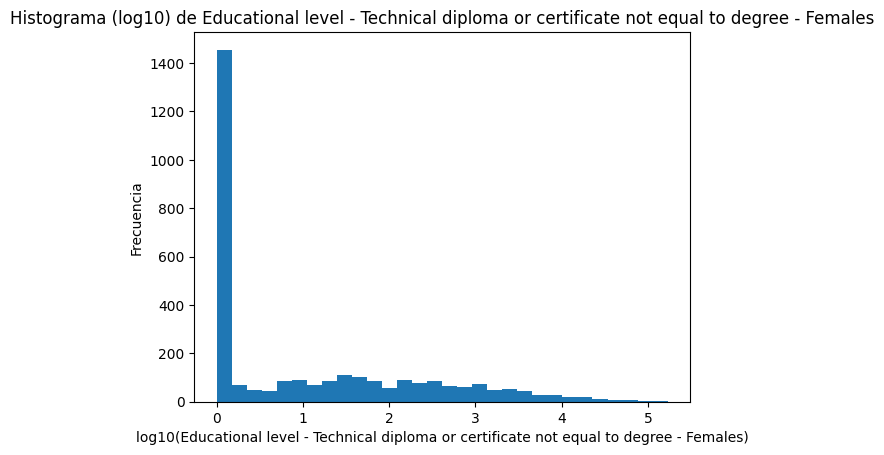

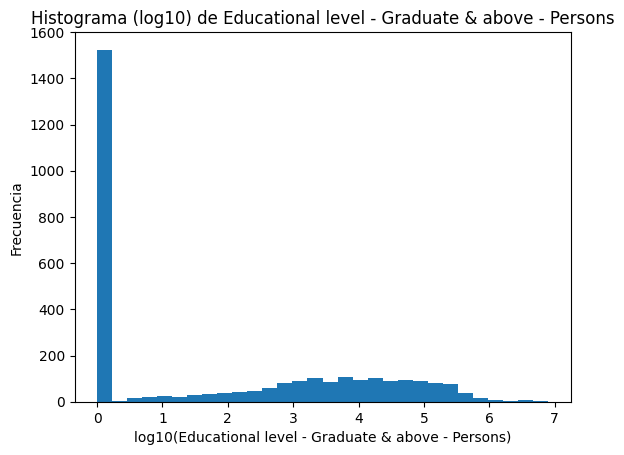

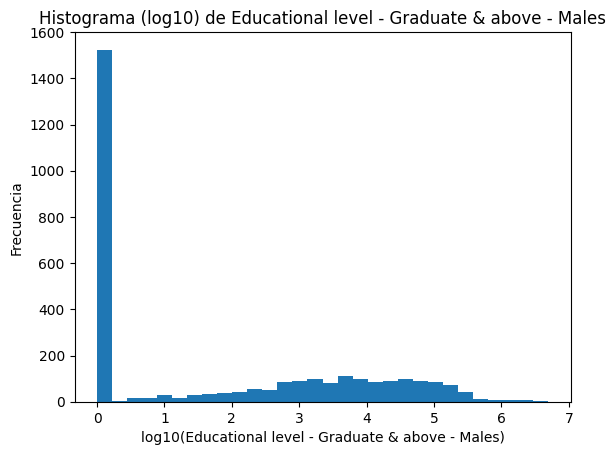

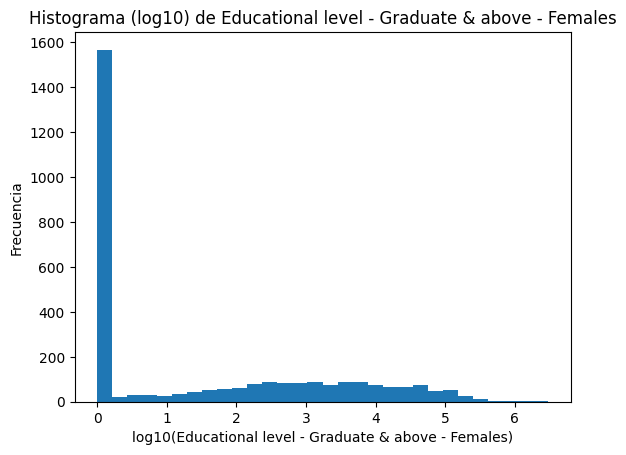

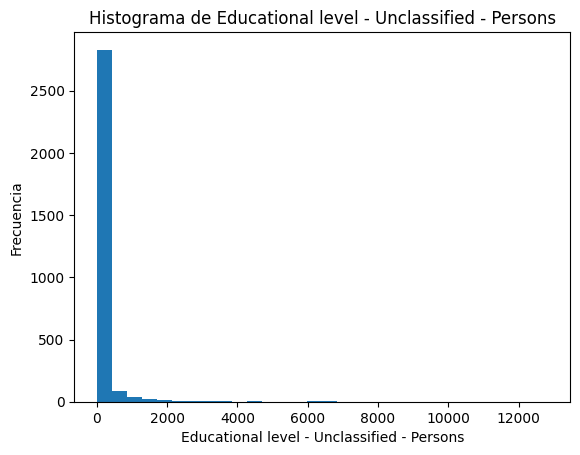

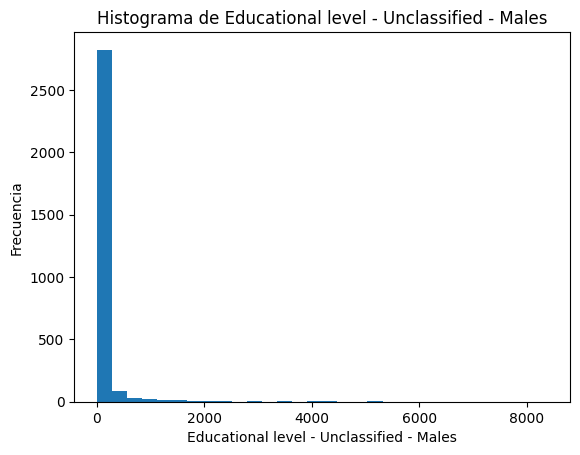

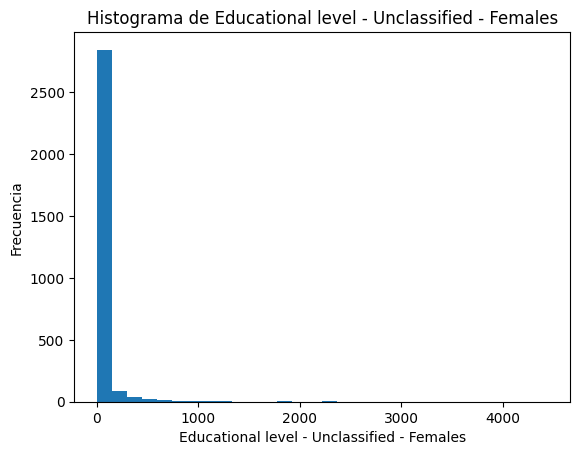

In [27]:
for col in columnas_num:
    
    plt.figure()
    
    if df_Educ[col].max() > 100000:  # si los valores son muy grandes
        plt.hist(np.log10(df_Educ[col] + 1), bins=30)
        plt.title(f"Histograma (log10) de {col}")
        plt.xlabel(f"log10({col})")
    else:
        plt.hist(df_Educ[col], bins=30)
        plt.title(f"Histograma de {col}")
        plt.xlabel(col)
    
    plt.ylabel("Frecuencia")
    plt.show()

Interpretación de los histogramas

Obviando las tres primeras variables que no aportan valor, como ya hemos indicado anteriormente, procedo a dar algunas pinceladas de lo reflejado en los histogramas totales.

Para que la visualización de los histogramas se vea clara, se ha aplicado una transformación logarítmica base 10 para reducir la asimetría en aquellas variables con alta dispersión y facilitar así su visualización, ya que la población en general presenta valores extremadamente dispersos.

Interpretación logarítmica base10: El eje X representa el logaritmo en base 10 de la población total. Por ejemplo, el valor de 6 equivale aproximadamente a 1.000.000 de personas.

Todos los histogramas de todas las variables que configuran el dataframe "df_Educ" reflejan que la distribución log-transformada se aproxima a la normalidad, lo que sugiere que la(s) variable(s) original(es) siguen aproximadamente una distribución log-normal. 

Veamos algunas conclusiones previas:

Total - persons: Poblacion total. 
El eje X abarca desde valores cercanos a 1 (10 personas) hasta más de 8 (100 millones), lo que confirma la enorme heterogeneidad de la población. 
Este gráfico refleja la variabilidad natural de las unidades censales (distritos, subdivisiones, estados): algunas muy pequeñas (rurales, 1.000 hab.) y otras muy grandes (urbanas, 10M hab.). Es una distribución típica de datos de población geográfica y sirve como referencia de tamaño para interpretar el resto de histogramas.


Illiterate - Persons: Población total analfabeta.
Es ligeramente asimétrica hacia la derecha. El grueso de las observaciones se concentra entre log10 3.5 y 5.5, lo que en términos reales equivale a situarse entre 3.000 y 300.000 personas analfabetas.
Este histograma presenta una alta variabilidad poblacional. El analfabetismo está presente de forma generalizada en casi todas las unidades censales, independientemente de su tamaño. No hay un corte abrupto en los valores bajos, lo que sugiere que incluso las unidades pequeñas tienen población analfabeta. Esto es coherente con un país como la India, donde históricamente el analfabetismo ha sido un fenómeno transversal y extendido.

Literate - persons: Población total alfabetizada.
El área central de la distribución se extiende entre 2.5 y 7.5, con el grueso concentrado entre 4 y 6.5 (es decir, entre 10.000 y 3 millones de personas alfabetizadas por unidad). La forma es ligeramente asimétrica hacia la derecha y más irregular que la de Illiterate.

Los valores alcanzados presentan magnitudes más altas (100 millones) frente a los valores de personas analfabetas, lo cual es coherente: en términos absolutos hay más personas alfabetizadas que analfabetas en la mayoría de las unidades censales, y los grandes estados contribuyen con cifras enormes.

Aquí aparece un detalle muy relevante: hay un pico aislado en log10 ≈ 0 (es decir, ~1 persona). Esto indica la presencia de valores extremadamente bajos o posibles ceros transformados (log10(1) = 0), que podrían corresponder a unidades censales sin prácticamente población alfabetizada, o a errores en los datos. 

Literate without educational level: Poblacion alfabetizada sin nivel educativo.
El grueso de las observaciones se concentra entre log10 2.5 y 4.5, lo que en términos reales equivale a 300 y 32.000 personas alfabetizadas sin nivel educativo.

Presenta también un pico en log10 ~ 0 (valores cercanos a 1), y la distribución principal se concentra mucho más a la izquierda que los anteriores. Esto indica que las personas que saben leer o escribir pero no tienen ningún nivel educativo formal reconocido son una fracción menor de la población total, pero están presentes en casi todas las unidades censales.

Education level – Bellow primary:
El pico en 0 existe (~110) pero es relativamente pequeño comparado con la distribución principal, que es robusta y centrada en 10⁴. Esto indica que casi todas las unidades censales tienen un volumen significativo de personas con educación por debajo de primaria. Es coherente: representa el tramo más básico, al alcance de casi cualquier comunidad rural o urbana. O dicho de otra manera: la mayoría de los estados/distritos tienen cantidades similares (en orden de magnitud) de personas con nivel educativo “Below primary”.

Educational level - Primary: Esto no es un comportamiento demográfico normal.
Es bastante parecida al histograma de “Below primary”, pero desplazada ligeramente hacia valores más altos. Esto tiene sentido: normalmente hay más personas que alcanzan primaria que personas que quedan por debajo de primaria.

El pico en 0 salta a ~325 y empieza a dominar visualmente. La distribución secundaria se mantiene amplia (10² a 10⁶) pero ya es claramente bimodal: muchas unidades con cero, y las que tienen población en este nivel se distribuyen razonablemente. El acceso a educación primaria en India aún es desigual, especialmente en zonas rurales remotas.

Educational level - Middle:
El pico en 0 alcanza ~650 y empieza a ser estructuralmente dominante. La distribución real se aplana y se vuelve más irregular. Esto refleja que completar la educación media requiere ya una infraestructura escolar que no está presente en muchas unidades censales pequeñas o rurales. La deserción escolar entre primaria y secundaria es uno de los problemas históricos más documentados del sistema educativo indio.

Educational level - Matric/Secondary:
Con un pico en 0 de ~975, este histograma ya está completamente dominado por ceros. La distribución real (unidades que sí tienen graduados de secundaria) se desplaza además hacia valores más bajos (10³ a 10⁵·⁵), indicando que incluso donde existe este nivel, el volumen absoluto de personas es menor. Aquí se materializa el abandono escolar masivo en la adolescencia.

Educational level - Higher secondary/Intermediate/Pre-University/Senior secondary:
Es el histograma más extremo del conjunto. El pico en 0 llega a ~1.300, y la distribución real apenas alcanza 10⁵·⁵ como máximo, concentrándose en valores bajos (10² a 10⁴). El pre-universitario en India está concentrado geográficamente en ciudades medias y grandes, siendo prácticamente inexistente en la mayoría de unidades censales del país. 

Education level - Non-technical diploma or certificate (not equal to degree):
Este histograma está a escala lineal.
El eje X llega hasta 75.000 personas, y prácticamente todo el volumen se concentra en valores cercanos a 0. Es la distribución más concentrada vista hasta ahora, con un pico de casi 3.000 unidades censales con valores mínimos. Los diplomas no técnicos no universitarios son una categoría muy residual en India, donde la formación profesional no universitaria históricamente ha tenido poco reconocimiento institucional.

Education level - Technical diploma or certificate (not equal to degree): 
El pico en 0 alcanza ~1.350, coherente con la tendencia del bloque anterior. Lo más llamativo aquí es que la distribución real (fuera del pico) es muy plana y de bajo volumen, sin llegar a superar las 100-110 unidades en ningún bin, y con un rango máximo de apenas 10⁵. Esto refleja que la formación técnica certificada está extremadamente concentrada en polos industriales y urbanos específicos, siendo prácticamente inexistente en el resto del país.

Educational level - Graduate & above:
Con ~1.500 unidades en el pico de 0, es de los más extremos en ese sentido. Sin embargo, la distribución real alcanza hasta 10⁵·⁵ y tiene una forma relativamente plana pero extendida (10² a 10⁵·⁵), lo que indica que donde hay graduados universitarios, los hay en cantidades apreciables. Esto es la huella de las grandes ciudades universitarias indias concentrando casi todo el capital educativo superior del país.

Educational level - Unclassified:
Este histograma también está en escala lineal, con un pico masivo (~2.800) en valores cercanos a 0 y una cola que llega hasta 12.000. Esta categoría es especialmente relevante para el EDA porque "Unclassified" puede significar cosas muy distintas: datos no declarados, categorías no reconocidas por el censo, o personas cuyo nivel educativo no pudo ser determinado. El volumen del pico sugiere que es una categoría de uso residual masivo en el dataset.


Conclusión final:
La lógica es completamente coherente con India: es un país donde la tasa de alfabetización ronda el 74-77%, pero con enormes disparidades regionales. Además, una fracción significativa de la población sabe leer sin haber completado ningún nivel escolar formal, lo que explica perfectamente el histograma 4.
Esto no es ruido ni error: es la señal estadística más importante del dataset. Significa que la inmensa mayoría de unidades censales tienen cero o prácticamente cero personas en los niveles educativos más altos. Es la huella cuantitativa de la pirámide educativa truncada de India.

Lo que estos histogramas describen conjuntamente es la pirámide educativa de India con base amplísima y cúspide muy estrecha.

Una unidad administrativa rural pequeña puede tener cientos de personas con educación primaria, pero literalmente cero personas con un título universitario o diploma técnico. No es un dato faltante, es la realidad socioeconómica de muchas zonas de India.

De hecho ese patrón creciente es en sí mismo uno de los hallazgos más interesantes de este análisis: la pirámide educativa se estrecha drásticamente conforme sube el nivel, y ese estrechamiento es tan pronunciado que en miles de unidades administrativas los niveles superiores tienen cero representación.

In [27]:
## En el histograma de la variable "Literate - persons", se ve una distancia claramente diferenciada entre la primera barra y el resto. 
## Estos valores nulos pueden ser errores o outliers o realidad. 
# Puede que en esa unidad administrativa o censal haya 0 personas alfabetizadas.

# India tiene una tasa de alfabetización en torno al 74%, lo que significa que en alguna zona más rural
# y desfavorecida siempre habrá alguna persona sin alfabetizar.

## veo qué variables contienen el valor "cero":

for col in columnas_num:
    zeros = (df_Educ[col] == 0).sum()
    if zeros > 0:
        print(f"{col}: {zeros} ceros")

State Code: 84 ceros
District Code: 3024 ceros
Tehsil Code: 3024 ceros
Illiterate - Males: 2 ceros
Literate - Persons: 108 ceros
Literate - Males: 108 ceros
Literate - Females: 108 ceros
Educational level - Literate without educational level - Persons: 123 ceros
Educational level - Literate without educational level - Males: 138 ceros
Educational level - Literate without educational level - Females: 145 ceros
Educational level - Below primary - Persons: 108 ceros
Educational level - Below primary - Males: 108 ceros
Educational level - Below primary - Females: 116 ceros
Educational level - Primary - Persons: 324 ceros
Educational level - Primary - Males: 325 ceros
Educational level - Primary - Females: 330 ceros
Educational level - Middle - Persons: 651 ceros
Educational level - Middle - Males: 654 ceros
Educational level - Middle - Females: 664 ceros
Educational level - Matric/Secondary - Persons: 977 ceros
Educational level - Matric/Secondary - Males: 980 ceros
Educational level - Mat

Tras este análisis previo del df_Educ, hay algunas cosas que me resultan extrañas. 

Veo que en el df existen duplicidades. Con la variable "Age-group" ya he comprobado que había etiquetas agregadas, como es el caso 
de la marca "All ages". 

He calculado el total de personas por nivel educativo. Los valores que he obtenido no me cuadran.

Buscando en internet cual es el total poblacional de la India según el censo del 2011, he visto que aproximadamente se sitúa en unos 1.200M. 
El total que tengo en este df es mucho más alto. Tiene pinta de que la variable "Literate - persons" sea un agregado del resto.
Voy a comprobarlo:

In [28]:
# Lista de columnas educativas en orden jerárquico (desde el menor nivel hasta los no clasificados)
education_cols = [
    "Illiterate - Persons",
    "Educational level - Literate without educational level - Persons",
    "Educational level - Below primary - Persons",
    "Educational level - Primary - Persons",
    "Educational level - Middle - Persons",
    "Educational level - Matric/Secondary - Persons",
    "Educational level - Higher secondary/Intermediate/Pre-University/Senior secondary - Persons",
    "Educational level - Non-technical diploma or certificate not equal to degree - Persons",
    "Educational level - Technical diploma or certificate not equal to degree - Persons",
    "Educational level - Graduate & above - Persons",
    "Educational level - Unclassified - Persons",
]

In [29]:
edu_totales = pd.Series(
    {col: df_Educ[col].sum() for col in education_cols}
)

edu_totales.index = [
    "Illiterate",
    "Literate w/o level",
    "Below Primary",
    "Primary",
    "Middle",
    "Matric/Secondary",
    "Higher Secondary",
    "Non-technical diploma",
    "Technical diploma",
    "Graduate & above",
    "Unclassified",
]

In [30]:
edu_totales["= Literate - Persons"] = df_Educ["Literate - Persons"].sum()
print(edu_totales)

Illiterate               1871690124
Literate w/o level         80091864
Below Primary             579325092
Primary                   586960188
Middle                    360907384
Matric/Secondary          316918884
Higher Secondary          151264860
Non-technical diploma       1544584
Technical diploma          14666720
Graduate & above          150680588
Unclassified                 391024
= Literate - Persons     2242751188
dtype: int64


In [31]:
## El total de personas alfabetizadas "Literate - persons" engloba a todas las personas con algún nivel educacional (excluyendo los analfabetos Illiterate)
literate_cols = [col for col in education_cols if col != "Illiterate - Persons"]

# Verificación: "Literate - persons" debe ser igual a la suma de todos los niveles educativos
literate_sum = df_Educ[literate_cols].sum(axis=1)
literate_total = df_Educ["Literate - Persons"]

assert (literate_sum == literate_total).all(), \
    "Literate - Persons' NO coincide con la suma de los niveles educativos"

print("Confirmado: 'Literate - Persons' engloba todos los niveles educativos (sin analfabetos)")

Confirmado: 'Literate - Persons' engloba todos los niveles educativos (sin analfabetos)


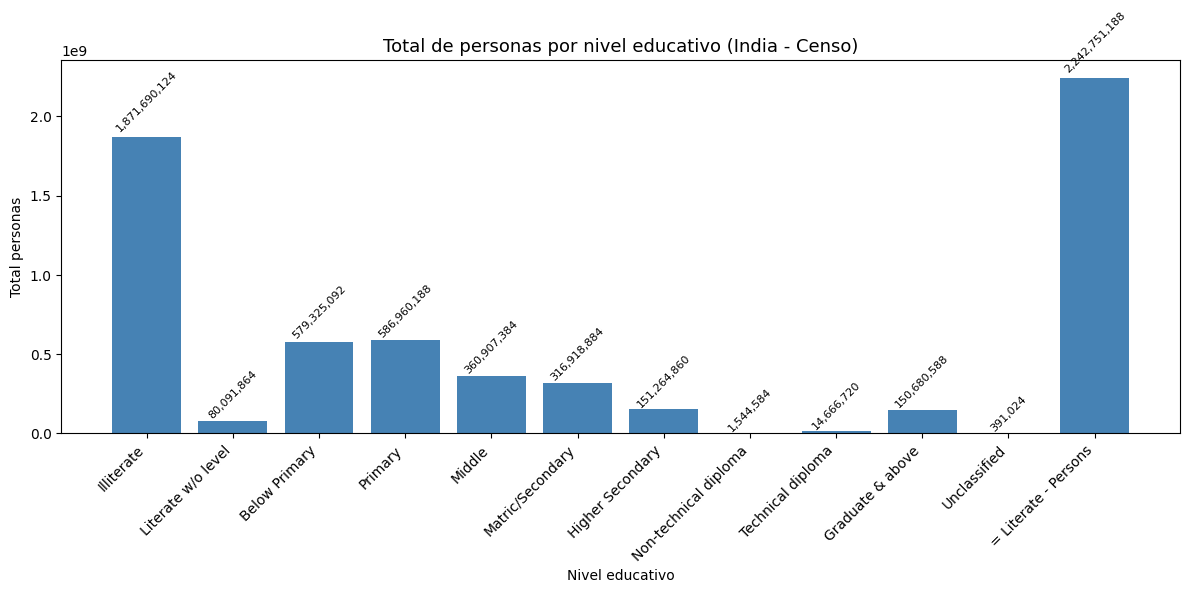

In [32]:
## Si esto lo muestro en un gráfico de barras:

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(edu_totales.index, edu_totales.values, color="steelblue")

# Añade las etiquetas de valor encima de cada barra
for bar, val in zip(bars, edu_totales.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() * 1.01,
        f"{val:,.0f}",
        ha="center", va="bottom", fontsize=8, rotation=45
    )

ax.set_title("Total de personas por nivel educativo (India - Censo)", fontsize=13)
ax.set_xlabel("Nivel educativo")
ax.set_ylabel("Total personas")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Por tanto, el fichero original requiere modificaciones. 
Por un lado ya sabemos que la variable "Literate - persons" engloba el resto de variables alfabetizadas. Hay que analizarla por separado del resto.
No podía ser que el total poblacional sea de 4000M de personas. El censo del 2011 indica un total de 1.200M.

Y por otro lado, el fichero presenta duplicidades. ¿Cuales? Estas que indico a continuación:

"Age - group", que ya habíamos visto que el valor "All ages" engloba el resto.

"Total/Rural/Urban" tiene valores agregados (Total). La idea es verificar si para cada unidad admva (estado/distrito/etc.) se cumple:

Total = Rural + Urban

"Area Name" además de los diferentes estados, tambien contiene valores correspondientes a India. Estos son valores agregados que engloban el resto.

Estas modificaciones las haré en el apartado de Limpieza.

In [33]:
df_Educ['Total/ Rural/ Urban'].value_counts()

Total/ Rural/ Urban
Total    1008
Rural    1008
Urban    1008
Name: count, dtype: int64

In [34]:
df_Educ.groupby(['State Code', 'District Code'])['Total/ Rural/ Urban'].nunique().value_counts()

Total/ Rural/ Urban
3    36
Name: count, dtype: int64

In [36]:
## Esto significa que cada unidad admva tiene sus tres versiones: Total, Rural y Urban.

## Compruebo si el total de personas es igual a la suma de Rural + Urban.

In [35]:
df_pivot = df_Educ.pivot_table(
    index=['State Code', 'District Code'],
    columns='Total/ Rural/ Urban',
    values='Total - Persons',
    aggfunc='sum'
)

df_pivot['check'] = df_pivot['Total'] == (df_pivot['Rural'] + df_pivot['Urban'])

df_pivot['check'].value_counts()

check
True    36
Name: count, dtype: int64

Se concluye que: Total = Urban + Rural

Por tanto, ya he comprobado que la variable Total/Rural/Urban la puedo usar de dos maneras:

1. Si mantengo las filas con valor "Total" entonces:

Procedo a realizar un análisis general por distrito/estado

2. Elimino las filas "Total": tendría un análisis más detallado comparando "Rural" vs "Urban"

# Análisis preliminar del dataset: df_Rank_final

In [36]:
## Compruebo estructura, características, columnas, tipos de variables, etc

df_Rank_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Institute ID    600 non-null    object 
 1   Institute Name  600 non-null    object 
 2   TLR             600 non-null    float64
 3   RPC             600 non-null    float64
 4   GO              600 non-null    float64
 5   OI              600 non-null    float64
 6   PERCEPTION      600 non-null    float64
 7   City            600 non-null    object 
 8   State           600 non-null    object 
 9   Score           600 non-null    float64
 10  Rank            600 non-null    int64  
 11  Año             600 non-null    int64  
dtypes: float64(6), int64(2), object(4)
memory usage: 56.4+ KB


El tipo de las variables es correcto. No tengo que cambiar ninguno. Tenemos dos tipos de variables, de tipo object y tipo float.

# Descripción de las variables del df_Rank_final (NIRF Ranking Completo)

Este conjunto de datos contiene datos oficiales de la clasificación NIRF (Marco Nacional de Clasificación Institucional) de las 100 mejores instituciones de la India durante varios años, de 2020 a 2025.

El Ministerio de Educación del Gobierno de la India publica anualmente los rankings NIRF, que evalúan a las instituciones de educación superior en función de la calidad docente, el rendimiento investigador, los resultados de graduación, la difusión y la reputación.

Cada institución se evalúa utilizando cinco parámetros principales:

• TLR (Enseñanza, Aprendizaje y Recursos)

• RPC (Investigación y Práctica Profesional)

• GO (Resultados de Graduación)

• OI (Difusión e Inclusión)

• Percepción (Percepción académica y de los empleadores)

Estos se combinan para formar la puntuación final, que determina la clasificación de la institución (variable Rank).

Cada fila del dataset representa una institución en un año.

VARIABLES:

 Institute ID: identificador único de la institución.

 Institute Name: Nombre oficial de la universidad o institución de educación superior.

 TLR (Enseñanza, Aprendizaje y Recursos): Puntuación que representa la calidad del profesorado, la capacidad estudiantil, las instalaciones y el entorno académico.        

 RPC (Investigación y Práctica Profesional): Puntuación que refleja las publicaciones de investigación, las patentes y el impacto en la práctica profesional.      

 GO (Resultados de Graduación): Puntuación basada en la colocación de los estudiantes, los estudios superiores y el rendimiento académico.         

 OI (Difusión e Inclusión): Puntuación que mide la diversidad, la representación regional, el equilibrio de género y la inclusión.  

 PERCEPTION: Puntuación de reputación derivada de colegas académicos y empleadores.   

 City: Ciudad donde se ubica la institución.    

 State: Estado o territorio de la Unión de la India de la institución. 

 Score: Puntuación general ponderada del NIRF, calculada utilizando todos los parámetros.  
      
 Rank: Clasificación nacional final asignada a la institución para ese año.    
 
 Año: Año de clasificación (2020-2025).       

In [37]:
# valores duplicados. 
df_Rank_final.duplicated().sum()

np.int64(0)

In [38]:
# ¿Hay alguna institución (o universidad) repetido dentro del mismo año?
df_Rank_final.duplicated(subset=['Institute ID', 'Año']).sum()

np.int64(0)

In [39]:
# valores vacios o nulos
df_Rank_final.isna().sum().sort_values(ascending=False)

Institute ID      0
Institute Name    0
TLR               0
RPC               0
GO                0
OI                0
PERCEPTION        0
City              0
State             0
Score             0
Rank              0
Año               0
dtype: int64

In [40]:
# algunos valores únicos relevantes para el análisis
df_Rank_final['State'].unique()

array(['Tamil Nadu', 'Karnataka', 'Maharashtra', 'Delhi', 'Uttar Pradesh',
       'West Bengal', 'Uttarakhand', 'Assam', 'Telangana', 'Jharkhand',
       'Rajasthan', 'Madhya Pradesh', 'Punjab', 'Gujarat', 'Odisha',
       'Chandigarh', 'Kerala', 'Andhra Pradesh', 'Bihar',
       'Jammu and Kashmir', 'Himachal Pradesh', 'Pondicherry',
       'Meghalaya'], dtype=object)

In [41]:
df_Rank_final['Institute Name'].unique()

array(['Indian Institute of Technology Madras',
       'Indian Institute of Science',
       'Indian Institute of Technology Bombay',
       'Indian Institute of Technology Delhi',
       'Indian Institute of Technology Kanpur',
       'Indian Institute of Technology Kharagpur',
       'Indian Institute of Technology Roorkee',
       'Indian Institute of Technology Guwahati',
       'Jawaharlal Nehru University', 'Banaras Hindu University',
       'Calcutta University', 'Amrita Vishwa Vidyapeetham',
       'Jamia Millia Islamia', 'Jadavpur University',
       'Manipal Academy of Higher Education',
       'Indian Institute of Technology Hyderabad',
       'University of Hyderabad', 'Aligarh Muslim University',
       'University of Delhi', 'Savitribai Phule Pune University',
       'Vellore Institute of Technology', 'Bharathiar University',
       'National Institute of Technology Tiruchirappalli',
       'Indian Institute of Science Education & Research Pune',
       'Anna University',

In [42]:
# número total de universidades distintas
df_Rank_final["Institute Name"].nunique()

171

In [43]:
df_Rank_final["Institute Name"].value_counts()

Institute Name
Indian Institute of Technology Madras                                          6
Banaras Hindu University                                                       6
Indian Institute of Technology Kanpur                                          6
Calcutta University                                                            6
Indian Institute of Technology Guwahati                                        6
                                                                              ..
International Institute of Information Technology Hyderabad                    1
Sher-e-Kashmir University of Agricultural Science and Technology of Kashmir    1
Manipal University Jaipur                                                      1
Madan Mohan Malaviya University of Technology                                  1
All India Institute of Medical Sciences Bhubaneswar                            1
Name: count, Length: 171, dtype: int64

Veamos a continuación cómo se comportan las variables de este df_Rank_final.

Podré hacer preguntas como ¿Cómo ha evolucionado el Score medio año a año, por universidades o por estados?.

Podré saber qué universidades han bajado o subido del ranking. 

Después, de cara al EDA, lo fusionaré con el dataset India_Education_Statistics ("df_Educ"), y calcularé
variables promedio de todos los indicadores del df_Rank_final, en donde tendré una fila por estado. Lo definiremos más adelante.

# 1 Estadísticas básicas de las variables numéricas del df_Rank_final

In [44]:
num_cols = ['TLR','RPC','GO','OI','PERCEPTION','Score','Rank']
df_Rank_final[num_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
TLR,600.0,63.81,9.44,39.94,56.75,63.56,70.86,90.58
RPC,600.0,39.67,16.51,10.35,28.16,38.11,47.41,92.51
GO,600.0,73.30,9.54,49.57,66.26,71.70,79.42,100.00
OI,600.0,61.15,7.68,36.58,55.38,60.34,66.08,83.83
PERCEPTION,600.0,24.42,21.76,0.00,9.70,17.89,29.47,100.00
Score,600.0,54.26,9.46,41.10,47.96,51.98,57.67,87.59
Rank,600.0,50.47,28.88,1.00,25.75,50.50,75.25,100.00


Conclusiones de las estadísticas básicas de df_Rank_final

TLR — Teaching, Learning & Resources.
Es el indicador más homogéneo junto con GO que ahora veremos. La media es prácticamente igual a la mediana, lo que indica una variablidad moderada. Esto quiere decir que no hay grandes diferencias en cuanto a infraestructura y docencia entre universidades.

RPC — Research & Professional Practice. 
Este es el más interesante. Tiene la mayor dispersión de todos los indicadores. Presenta un rango más amplio, lo que significa que hay diversidad de universidades en cuanto a investigación y práctica profesional. Es decir, habrá universidades casi sin actividad investigadora junto a otras que deben destacar. 

GO — Graduation Outcomes.
Este indicador presenta la media más alta. Esto quiere decir que las universidades del ranking tienen buenos resultados de graduación en general. 

OI — Outreach & Inclusivity.
Presenta una distribución más explícita, puesto que presenta una desviación típica pequeña. Esto dice que todas las universidades se comportan de forma parecida en inclusividad — es el criterio donde menos se diferencian. Puede ser porque hay una política nacional que empuja a todas hacia niveles similares.

PERCEPTION
El más sesgado con diferencia. La mediana es 17.9 pero el máximo es 100. Eso significa que unas pocas universidades acaparan toda la percepción pública y el resto tiene valores muy bajos. La desviación típica casi iguala a la media, lo cual es señal clara de distribución muy asimétrica. Este indicador castiga enormemente a universidades que académicamente pueden ser buenas pero no son conocidas.

Score total.
El rango va de 41 a 87 puntos. La distribución es bastante comprimida — entrar en el top 100 ya implica un umbral mínimo de calidad. La diferencia entre el puesto 1 (87.5) y el puesto 100 (≈41) es de unos 46 puntos.

Conclusión general: en el caso de predecir o explicar el ranking, me quedaría con la variable RPC. Es la que más variabilidad tiene, la que más discrimina, y probablemente la que más correlacione con el Score final. 

# Histogramas de las variables numéricas

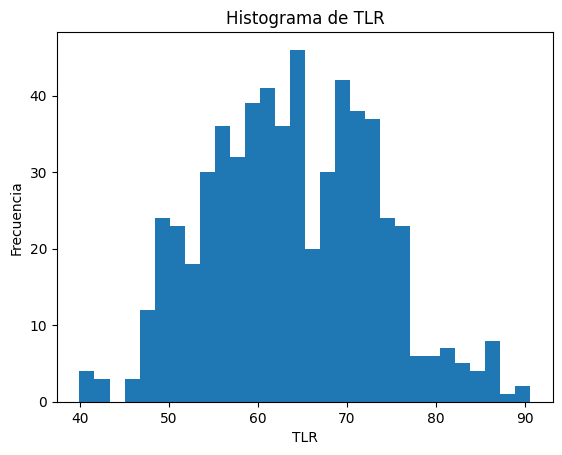

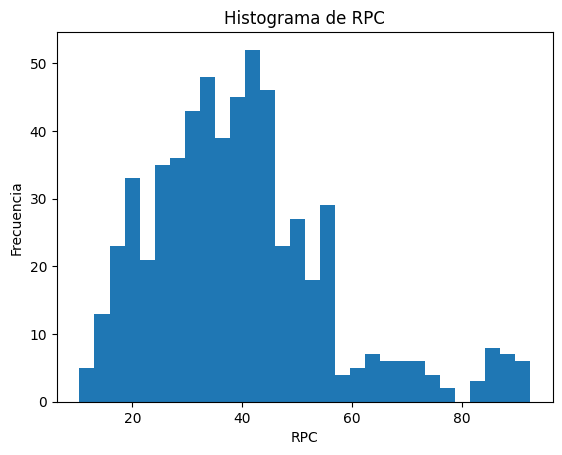

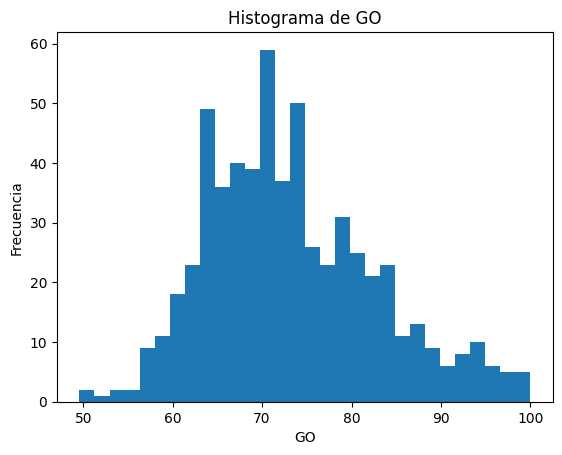

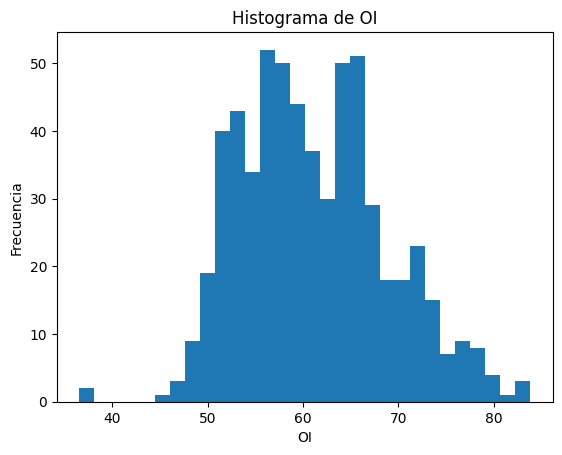

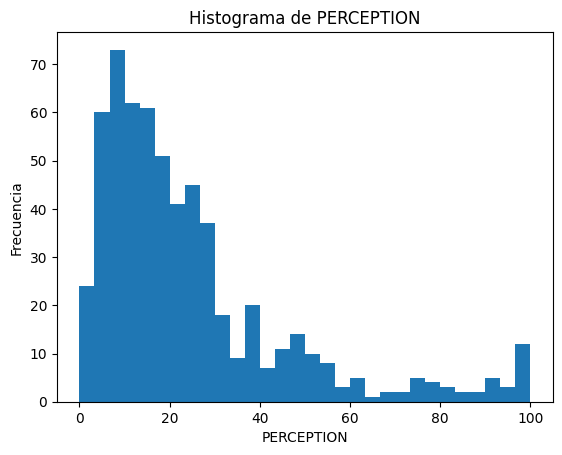

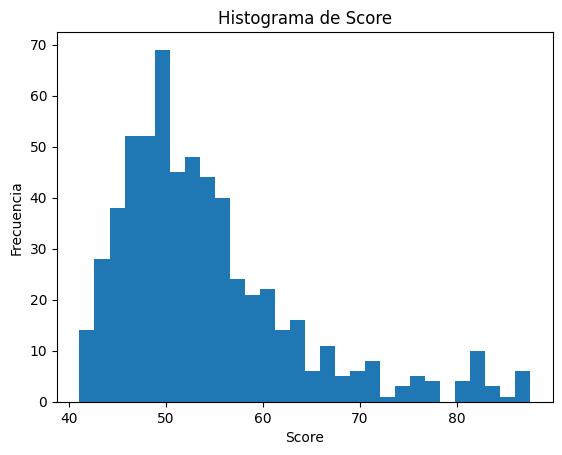

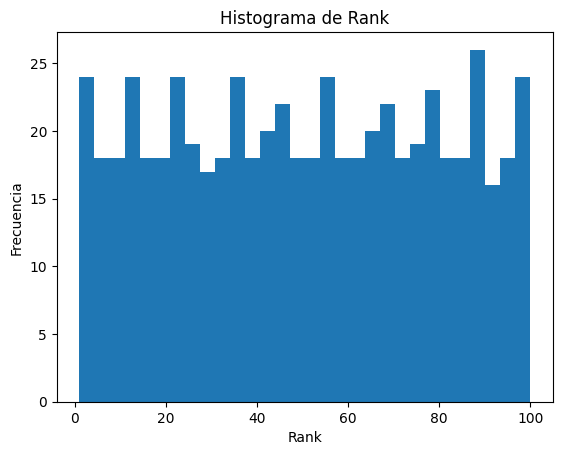

In [45]:
for col in num_cols:
    
    plt.figure()
    
    if df_Rank_final[col].max() > 100000:  # si los valores son muy grandes
        plt.hist(np.log10(df_Rank_final[col] + 1), bins=30)
        plt.title(f"Histograma (log10) de {col}")
        plt.xlabel(f"log10({col})")
    else:
        plt.hist(df_Rank_final[col], bins=30)
        plt.title(f"Histograma de {col}")
        plt.xlabel(col)
    
    plt.ylabel("Frecuencia")
    plt.show()

Interpretación de los histogramas

Para añadir conclusiones a lo ya visto anteriormente, vamos a interpretar los gráficos:

TLR: muestra una distribución aproximadamente normal (casi simétrica), lo que sugiere que las universidades tienen niveles similares en cuanto a la calidad de los docentes y recursos, con algunas instituciones destacando ligeramente por encima del promedio. 

Esto indica que no parece haber grandes desigualdades entre universidades teniendo en cuenta este indicador.
El pico principal parece alrededor de 60-65 puntos. Solo unas pocas instituciones destacan claramente con valores cercanos a 90.

RPC: Muestra una distribución asimétrica hacia la derecha. El pico principal está aproximadamente en 35-40 puntos.
Gran concentración entre 20 y 50 puntos.

Presenta una mayor dispersión respecto al indicador anterior, lo cual significa que hay más desigualdad entre universidades que destaquen por la investigación.
Solo algunas instituciones destacan fuertemente en investigación, mientras que la mayoría presenta niveles medios o bajos.

GO: La distribución es asimétrica a la derecha. La mayoría de universidades se concentran entre 65 y 80 puntos, con el pico máximo alrededor de 70-72.
Lo más llamativo es la cola derecha pronunciada: hay un grupo relevante de universidades con valores muy altos de graduación, entre 85 y 100. Estas serán las universidades más importantes del país, las élites, donde prácticamente todos los estudiantes se gradúan, consiguen empleo o continúan estudiando.

OI: Distribución con forma aproximadamente normal o unimodal, con la mayor concentración de valores entre 55 y 70. El conjunto de datos tiende a concentrarse en valores medios, con relativamente pocas instituciones mostrando niveles muy bajos o muy altos en esta dimensión.
Se confirma que es el indicador más homogéneo.

PERCEPTION: Es el histograma más llamativo con diferencia. Distribución con sesgo extremo a la derecha. Hay universidades con una reputación y empleabilidad por debajo de 20, mientras que un pequeño grupo alcanza valores de 80-100. Este escaso grupo corresponde a las universidades de élite. Hay mucha diferencia, lo cual este indicador nos muestra que una universidad puede ser excelente en docencia e investigación pero tener una reputación baja simplemente porque no es conocida fuera de su región. Esto me lleva a creer que es el indicador más injusto del sistema NIRF.

Score — Puntuación global. 
Distribución con sesgo a la derecha, heredado directamente de PERCEPTION. La masa principal se concentra entre 45-60, con un pico en torno a 50-52. A partir de 65 la frecuencia cae drásticamente, y los valores por encima de 75 corresponden a un grupo de universidades de élite absoluta.
Esto revela una estructura muy jerarquizada: hay un grupo grande y compacto de universidades "buenas" en la banda 45-62, y luego un salto cualitativo enorme hasta las 10-15 instituciones que superan 70. La diferencia entre el puesto 15 y el puesto 1 es probablemente mayor que la diferencia entre el puesto 50 y el puesto 15.

Tras este análisis de histogramas, voy a sacar algunas conclusiones más antes de modificar el df a la hora de la fusión con el otro df_Educ.

Primero conviene verificar si todas las instituciones aparecen el mismo número de años.

Si todas aparecen los mismos años.

Si hay universidades que entran o salen del ranking. Qué universidades han subido o bajado de nivel año tras año.

In [46]:
## Quiero saber si todas las universidades se mantienen en el ranking todos los años.
df_Rank_final.groupby("Institute Name")["Año"].nunique().value_counts()

Año
6    51
1    47
2    25
5    22
3    17
4     9
Name: count, dtype: int64

El dataset muestra que solo 51 instituciones (o universidades) aparecen en todos los años del ranking (6 años). Sin embargo, una proporción considerable de universidades aparece en menos años, e incluso 47 universidades aparecen únicamente en un año, lo que sugiere que el ranking tiene una alta rotación de universidades a lo largo del tiempo.

Conclusión: Muchas universidades entran o salen del Top 100.

In [47]:
df_Rank_final["Institute Name"].value_counts()

Institute Name
Indian Institute of Technology Madras                                          6
Banaras Hindu University                                                       6
Indian Institute of Technology Kanpur                                          6
Calcutta University                                                            6
Indian Institute of Technology Guwahati                                        6
                                                                              ..
International Institute of Information Technology Hyderabad                    1
Sher-e-Kashmir University of Agricultural Science and Technology of Kashmir    1
Manipal University Jaipur                                                      1
Madan Mohan Malaviya University of Technology                                  1
All India Institute of Medical Sciences Bhubaneswar                            1
Name: count, Length: 171, dtype: int64

In [48]:
años_ranking = df_Rank_final.groupby("Institute Name")["Año"].nunique()
años_ranking

Institute Name
Acharya Nagarjuna University                             1
Alagappa University                                      6
Aligarh Muslim University                                6
All India Institute of Medical Sciences Bhubaneswar      1
All India Institute of Medical Sciences Delhi            1
                                                        ..
Visva Bharati                                            2
Visvesvaraya National Institute of Technology            2
Visvesvaraya National Institute of Technology Nagpur     1
Visvesvaraya National Institute of Technology, Nagpur    3
Visvesvaraya Technological University                    2
Name: Año, Length: 171, dtype: int64

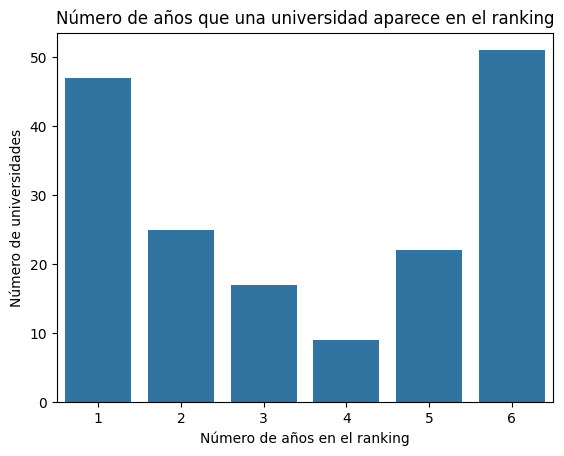

In [49]:
# Gráfico que muestra cuántas universidades han aparecido en el ranking durante 1 a 6 años consecutivos:
sns.countplot(x=años_ranking)

plt.title("Número de años que una universidad aparece en el ranking")
plt.xlabel("Número de años en el ranking")
plt.ylabel("Número de universidades")

plt.show()

Esto sugiere que existe un núcleo relativamente estable de universidades de alto rendimiento, junto con un grupo más amplio de universidades cuya presencia en el ranking es más variable a lo largo del tiempo.

Tendencia descendente al principio (de 1 a 4 años)
La mayoría de universidades que entran al ranking no logran mantenerse: 47 entraron el primer año, pero solo 9 llegaron al cuarto año. Esto sugiere alta rotación o dificultad para consolidarse.

Rebote sorprendente en el año 5 y 6.
A partir del año 5 la tendencia se invierte, y en el año 6 hay el mayor número de universidades (51). Esto indica la existencia de dos grupos muy distintos:

Universidades "transitorias": aparecen 1-2 años y desaparecen del ranking.
Universidades consolidadas: llevan 6 años seguidos en el ranking y son las más estables y consistentes.

Continuando con el análisis, vamos a mostrar una evolución del ranking por universidad.

Variable "Rank": ¿Cambia el ranking del Top 100 universidades a lo largo del tiempo?

In [50]:
# Universidades que más suben o bajan de Ranking entre 2020 y 2025
df_pivot = df_Rank_final.pivot(index="Institute Name", columns="Año", values="Rank")
df_pivot["variacion"] = df_pivot[2020] - df_pivot[2025]  # positivo = sube
df_pivot.sort_values("variacion", ascending=False)

Año,2020,2021,2022,2023,2024,2025,variacion
Institute Name,,,,,,,
Chandigarh University,77.0,77.0,48.0,45.0,32.0,32.0,45.0
Lovely Professional University,81.0,81.0,58.0,46.0,45.0,49.0,32.0
S.R.M. Institute of Science and Technology,53.0,53.0,36.0,32.0,21.0,22.0,31.0
Bharathidasan University,90.0,90.0,82.0,70.0,55.0,61.0,29.0
Symbiosis International,68.0,68.0,62.0,59.0,52.0,40.0,28.0
...,...,...,...,...,...,...,...
Visva Bharati,97.0,97.0,NaN,NaN,NaN,NaN,NaN
Visvesvaraya National Institute of Technology,54.0,54.0,NaN,NaN,NaN,NaN,NaN
Visvesvaraya National Institute of Technology Nagpur,NaN,NaN,NaN,NaN,77.0,NaN,NaN


In [53]:
## Gracias a este resumen de datos, veo que los nombres de las universidades hay que normalizarlas. La universidad "Visvesvaraya ..."
## aparece dos veces, diferenciándose por una "coma". 
## También veo que los resultados de 2020 vs 2021 son iguales. No sé si esto es por algo. ¿Es posible que haya mantenido todo igual, en los dos primeros años?

In [51]:
normalization_map = {
    "Indian Institute of Science Education & Research Pune": "Indian Institute of Science Education and Research Pune",
    "Indian Institute of Science Education & Research, Pune": "Indian Institute of Science Education and Research Pune",
    "Indian Institute of Science Education & Research Kolkata": "Indian Institute of Science Education and Research Kolkata",
    "Indian Institute of Science Education & Research, Kolkata": "Indian Institute of Science Education and Research Kolkata",
    "Indian Institute of Science Education & Research, Mohali": "Indian Institute of Science Education and Research Mohali",
    "Indian Institute of Science Education & Research Mohali": "Indian Institute of Science Education and Research Mohali",
    "Indian Institute of Science Education and Research Mohali": "Indian Institute of Science Education and Research Mohali",
    "Indian Institute of Science Education & Research Bhopal": "Indian Institute of Science Education and Research Bhopal",
    "Indian Institute of Technology (Indian School of Mines), Dhanbad": "Indian Institute of Technology (Indian School of Mines) Dhanbad",
    "Thapar Institute of Engineering and Technology (Deemed-to-be-university)": "Thapar Institute of Engineering and Technology",
    "Dr. B. R. Ambedkar National Institute of Technology": "Dr. B R Ambedkar National Institute of Technology Jalandhar",
    "Dr. B R Ambedkar National Institute of Technology, Jalandhar": "Dr. B R Ambedkar National Institute of Technology Jalandhar",
    "University of Petroleum and Energy Studies": "UPES",
    "Birla Institute of Technology & Science -Pilani": "Birla Institute of Technology and Science Pilani",
    "Calcutta University": "University of Calcutta",
    "Mumbai University": "University of Mumbai",
    "Kerala University": "University of Kerala",
    "Mysore University": "University of Mysore",
}

def normalize_institute(name):
    if not isinstance(name, str):
        return name
    return normalization_map.get(name.strip(), name.strip())

df_Rank_final["Institute Name"] = df_Rank_final["Institute Name"].apply(normalize_institute)

df_Rank_final["Institute Name"].value_counts()

Institute Name
Indian Institute of Technology Madras                                          6
Indian Institute of Technology Kanpur                                          6
Indian Institute of Technology Indore                                          6
Banaras Hindu University                                                       6
Jawaharlal Nehru University                                                    6
                                                                              ..
International Institute of Information Technology Hyderabad                    1
Sher-e-Kashmir University of Agricultural Science and Technology of Kashmir    1
Manipal University Jaipur                                                      1
Madan Mohan Malaviya University of Technology                                  1
All India Institute of Medical Sciences Bhubaneswar                            1
Name: count, Length: 162, dtype: int64

In [52]:
counts = df_Rank_final["Institute Name"].value_counts()

# Institutos que solo aparecen 1 vez (sospechosos de ser variantes)
sospechosos = counts[counts == 1]
print(f"Institutos con solo 1 aparición: {len(sospechosos)}")
print(sospechosos)

Institutos con solo 1 aparición: 40
Institute Name
Indian Institute of Technology, Bombay                                         1
Indian Institute of Technology, Mandi                                          1
Indian Institute of Technology, Gandhinagar                                    1
Birla Institute of Technology & Science - Pilani                               1
Indian Institute of Technology, Delhi                                          1
Indian Institute of Technology, Kharagpur                                      1
Indian Institute of Technology, Roorkee                                        1
Jamia Millia Islamia, New Delhi                                                1
Bangalore University                                                           1
Jamia Millia Islamia,New Delhi                                                 1
National Institute of Technology, Silchar                                      1
Indian Institute of Management Kozhikode                  

In [53]:
normalization_map.update({
    # IITs con coma
    "Indian Institute of Technology, Bombay": "Indian Institute of Technology Bombay",
    "Indian Institute of Technology, Mandi": "Indian Institute of Technology Mandi",
    "Indian Institute of Technology, Gandhinagar": "Indian Institute of Technology Gandhinagar",
    "Indian Institute of Technology, Delhi": "Indian Institute of Technology Delhi",
    "Indian Institute of Technology, Kharagpur": "Indian Institute of Technology Kharagpur",
    "Indian Institute of Technology, Roorkee": "Indian Institute of Technology Roorkee",
    "Indian Institute of Technology, Patna": "Indian Institute of Technology Patna",

    # NITs con coma
    "National Institute of Technology, Silchar": "National Institute of Technology Silchar",
    "National Institute of Technology, Tiruchirappalli": "National Institute of Technology Tiruchirappalli",

    # BITS variante con espacio diferente
    "Birla Institute of Technology & Science - Pilani": "Birla Institute of Technology and Science Pilani",
    "Birla Institute of Technology and Science, Pilani": "Birla Institute of Technology and Science Pilani",

    # Jamia Millia variantes
    "Jamia Millia Islamia, New Delhi": "Jamia Millia Islamia",
    "Jamia Millia Islamia,New Delhi": "Jamia Millia Islamia",

    # AIIMS variantes
    "All India Institute of Medical Sciences, Rishikesh": "All India Institute of Medical Sciences Rishikesh",

    # Indian Institute of Science variante
    "Indian Institute of Science, Bengaluru": "Indian Institute of Science",

    # JIPMER variante
    "Jawaharlal Institute of Post Graduate Medical Education and Research": "Jawaharlal Institute of Post Graduate Medical Education & Research",

    # Punjab Agricultural University con coma
    "Punjab Agricultural University, Ludhiana": "Punjab Agricultural University",

    # NIMHANS con coma
    "National Institute of Mental Health & Neuro Sciences, Bangalore": "National Institute of Mental Health & Neuro Sciences Bangalore",

    # Shanmugha variante
    "Shanmugha Arts Science Technology and Research Academy": "Shanmugha Arts Science Technology & Research Academy",

    # Bharath Institute variante
    "Bharath Institute of Higher Education and Research": "Bharath Institute of Higher Education & Research",

    # Bangalore University (ya aparece como tal, es único)
    "Bangalore University": "Bangalore University",
})

# Vuelve a aplicar
df_Rank_final["Institute Name"] = df_Rank_final["Institute Name"].apply(normalize_institute)

# Comprueba cuántos únicos quedan
print(df_Rank_final["Institute Name"].value_counts())

Institute Name
Indian Institute of Technology Madras                                          6
Indian Institute of Science                                                    6
Indian Institute of Technology Bombay                                          6
Indian Institute of Technology Delhi                                           6
Indian Institute of Technology Kanpur                                          6
                                                                              ..
International Institute of Information Technology Hyderabad                    1
Sher-e-Kashmir University of Agricultural Science and Technology of Kashmir    1
Manipal University Jaipur                                                      1
Madan Mohan Malaviya University of Technology                                  1
All India Institute of Medical Sciences Bhubaneswar                            1
Name: count, Length: 143, dtype: int64


In [54]:
counts = df_Rank_final["Institute Name"].value_counts()
sospechosos = counts[counts == 1]
print(f"Institutos con solo 1 aparición: {len(sospechosos)}")
print(sospechosos)

Institutos con solo 1 aparición: 21
Institute Name
Indian Institute of Management Kozhikode                                       1
Bangalore University                                                           1
Indian Institute of Management Calcutta                                        1
All India Institute of Medical Sciences Delhi                                  1
Indian Institute of Technology (Indian School of Mines) Dhanbad                1
Andhra University                                                              1
Babasaheb Bhimrao Ambedkar University                                          1
Indian Statistical Institute, Kolkata                                          1
Visvesvaraya National Institute of Technology Nagpur                           1
Shoolini University of Biotechnology and Management Sciences                   1
Acharya Nagarjuna University                                                   1
All India Institute of Medical Sciences Patna             

In [55]:
normalization_map.update({
    # IIT ISM Dhanbad - aún tiene una variante sin normalizar
    "Indian Institute of Technology (Indian School of Mines) Dhanbad": 
        "Indian Institute of Technology (Indian School of Mines) Dhanbad",
    
    # Indian Statistical Institute con coma
    "Indian Statistical Institute, Kolkata": "Indian Statistical Institute Kolkata",

    # AIIMS Delhi - falta en el mapa
    "All India Institute of Medical Sciences Delhi": "All India Institute of Medical Sciences Delhi",
})

df_Rank_final["Institute Name"] = df_Rank_final["Institute Name"].apply(normalize_institute)

In [56]:
for keyword in ["Visvesvaraya", "AIIMS", "Andhra"]:
    matches = df_Rank_final["Institute Name"].str.contains(keyword, case=False, na=False)
    print(df_Rank_final.loc[matches, "Institute Name"].value_counts())
    print("---")

Institute Name
Visvesvaraya National Institute of Technology, Nagpur    3
Visvesvaraya National Institute of Technology            2
Visvesvaraya Technological University                    2
Visvesvaraya National Institute of Technology Nagpur     1
Name: count, dtype: int64
---
Series([], Name: count, dtype: int64)
---
Institute Name
Andhra University, Visakhapatnam    5
Andhra University                   1
Name: count, dtype: int64
---


In [57]:
normalization_map.update({
    # Visvesvaraya NIT - tres variantes del mismo instituto
    "Visvesvaraya National Institute of Technology, Nagpur": "Visvesvaraya National Institute of Technology Nagpur",
    "Visvesvaraya National Institute of Technology": "Visvesvaraya National Institute of Technology Nagpur",

    # Andhra University con ciudad
    "Andhra University, Visakhapatnam": "Andhra University",
})

df_Rank_final["Institute Name"] = df_Rank_final["Institute Name"].apply(normalize_institute)

# Verificar
counts = df_Rank_final["Institute Name"].value_counts()
sospechosos = counts[counts == 1]
print(f"Institutos con solo 1 aparición: {len(sospechosos)}")
print(sospechosos)

Institutos con solo 1 aparición: 19
Institute Name
Indian Institute of Management Kozhikode                                       1
Bangalore University                                                           1
Indian Institute of Management Calcutta                                        1
All India Institute of Medical Sciences Delhi                                  1
Indian Institute of Technology (Indian School of Mines) Dhanbad                1
Babasaheb Bhimrao Ambedkar University                                          1
Indian Statistical Institute Kolkata                                           1
Shoolini University of Biotechnology and Management Sciences                   1
Acharya Nagarjuna University                                                   1
All India Institute of Medical Sciences Patna                                  1
Periyar University                                                             1
Indian Agricultural Research Institute                    

In [58]:
print(f"Valores únicos finales: {df_Rank_final['Institute Name'].nunique()}")
print(f"Total filas: {len(df_Rank_final)}")

Valores únicos finales: 140
Total filas: 600


In [59]:
for instituto in sorted(df_Rank_final["Institute Name"].unique()):
    print(instituto)

Acharya Nagarjuna University
Alagappa University
Aligarh Muslim University
All India Institute of Medical Sciences Bhubaneswar
All India Institute of Medical Sciences Delhi
All India Institute of Medical Sciences Jodhpur
All India Institute of Medical Sciences Patna
All India Institute of Medical Sciences Rishikesh
All India Institute of Medical Sciences, Delhi
Amity University
Amrita Vishwa Vidyapeetham
Andhra University
Anna University
Babasaheb Bhimrao Ambedkar University
Babasheb Bhimrao Ambedkar University
Banaras Hindu University
Banasthali Vidyapith
Bangalore University
Bharath Institute of Higher Education & Research
Bharathiar University
Bharathidasan University
Birla Institute of Technology  & Science -Pilani
Birla Institute of Technology and Science Pilani
Calicut University
Chandigarh University
Christ University
Cochin University of Science and Technology
Datta Meghe Institute of Higher Education and Research
Datta Meghe Institute of Medical Sciences
Delhi Technological Un

In [60]:
normalization_map.update({
    # AIIMS Delhi
    "All India Institute of Medical Sciences, Delhi": "All India Institute of Medical Sciences Delhi",

    # Babasaheb variante
    "Babasheb Bhimrao Ambedkar University": "Babasaheb Bhimrao Ambedkar University",

    # BITS variante con doble espacio
    "Birla Institute of Technology  & Science -Pilani": "Birla Institute of Technology and Science Pilani",

    # Calicut University
    "Calicut University": "University of Calicut",

    # Datta Meghe variante
    "Datta Meghe Institute of Higher Education and Research": "Datta Meghe Institute of Medical Sciences",

    # IIEST Shibpur
    "Indian Institute of Engineering Science and Technology, Shibpur": "Indian Institute of Engineering Science and Technology",

    # IIT ISM sin ciudad
    "Indian Institute of Technology (Indian School of Mines)": "Indian Institute of Technology (Indian School of Mines) Dhanbad",

    # Mahatma Gandhi University con ciudad
    "Mahatma Gandhi University, Kottayam": "Mahatma Gandhi University",

    # Manipal variantes
    "Manipal Academy of Higher Education, Manipal": "Manipal Academy of Higher Education",
    "Manipal Academy of Higher Education-Manipal": "Manipal Academy of Higher Education",

    # NIT Karnataka con ciudad
    "National Institute of Technology Karnataka, Surathkal": "National Institute of Technology Karnataka",
})

df_Rank_final["Institute Name"] = df_Rank_final["Institute Name"].apply(normalize_institute)

# Verificar
counts = df_Rank_final["Institute Name"].value_counts()
sospechosos = counts[counts == 1]
print(f"Valores únicos finales: {df_Rank_final['Institute Name'].nunique()}")
print(f"Institutos con solo 1 aparición: {len(sospechosos)}")

Valores únicos finales: 130
Institutos con solo 1 aparición: 16


In [61]:
for instituto in sorted(df_Rank_final["Institute Name"].unique()):
    print(instituto)

Acharya Nagarjuna University
Alagappa University
Aligarh Muslim University
All India Institute of Medical Sciences Bhubaneswar
All India Institute of Medical Sciences Delhi
All India Institute of Medical Sciences Jodhpur
All India Institute of Medical Sciences Patna
All India Institute of Medical Sciences Rishikesh
Amity University
Amrita Vishwa Vidyapeetham
Andhra University
Anna University
Babasaheb Bhimrao Ambedkar University
Banaras Hindu University
Banasthali Vidyapith
Bangalore University
Bharath Institute of Higher Education & Research
Bharathiar University
Bharathidasan University
Birla Institute of Technology and Science Pilani
Chandigarh University
Christ University
Cochin University of Science and Technology
Datta Meghe Institute of Medical Sciences
Delhi Technological University
Dr. B R Ambedkar National Institute of Technology Jalandhar
Dr. D. Y. Patil Vidyapeeth
Gauhati University
Graphic Era University
Gujarat University
Guru Gobind Singh Indraprastha University
Guru Nan

In [62]:
normalization_map.update({
    # University of Calicut y Calicut University son el mismo
    # (ya lo tienes correcto)
    
    # Motilal Nehru NIT - falta ciudad
    "Motilal Nehru National Institute of Technology": "Motilal Nehru National Institute of Technology Allahabad",
})

df_Rank_final["Institute Name"] = df_Rank_final["Institute Name"].apply(normalize_institute)

In [63]:
df_Rank_final["Institute Name"].str.contains("Visva", case=False).sum()

np.int64(2)

In [64]:
df_Rank_final[df_Rank_final["Institute Name"].str.contains("Visva", case=False)]["Institute Name"].value_counts()

Institute Name
Visva Bharati    2
Name: count, dtype: int64

In [65]:
df_Rank_final["Institute Name"].value_counts().head(100)

Institute Name
Indian Institute of Technology Madras                6
Indian Institute of Science                          6
Indian Institute of Technology Bombay                6
Indian Institute of Technology Delhi                 6
Indian Institute of Technology Kanpur                6
                                                    ..
National Institute of Technology Calicut             3
University of Jammu                                  3
Tezpur University                                    3
All India Institute of Medical Sciences Rishikesh    3
Graphic Era University                               3
Name: count, Length: 100, dtype: int64

Tras esta normalización, compruebo si el número de universidades se ha reducido tras esta limpieza.

Debería bajar de 171

In [66]:
## Cuento el número total de universidades tras la limpieza
print(df_Rank_final["Institute Name"].nunique())  

130


In [67]:
# De nuevo actualizo la variación de antes: Universidades que más suben o bajan de Ranking entre 2020 y 2025
df_pivot = df_Rank_final.pivot(index="Institute Name", columns="Año", values="Rank")
df_pivot["variacion"] = df_pivot[2020] - df_pivot[2025]  # positivo = sube
df_pivot.sort_values("variacion", ascending=False)

Año,2020,2021,2022,2023,2024,2025,variacion
Institute Name,,,,,,,
Chandigarh University,77.0,77.0,48.0,45.0,32.0,32.0,45.0
Lovely Professional University,81.0,81.0,58.0,46.0,45.0,49.0,32.0
S.R.M. Institute of Science and Technology,53.0,53.0,36.0,32.0,21.0,22.0,31.0
Bharathidasan University,90.0,90.0,82.0,70.0,55.0,61.0,29.0
Symbiosis International,68.0,68.0,62.0,59.0,52.0,40.0,28.0
...,...,...,...,...,...,...,...
University of Calicut,95.0,95.0,NaN,NaN,NaN,NaN,NaN
University of Jammu,NaN,NaN,93.0,NaN,87.0,87.0,NaN
University of Mysore,34.0,34.0,54.0,71.0,86.0,NaN,NaN


In [68]:
# Calculo de nuevo la variación de las universidades que se mantienen los 6 años, para obtener un resumen más claro:

df_pivot_completo = df_pivot.dropna()
print(f"Institutos presentes los 6 años: {len(df_pivot_completo)}")
df_pivot_completo.sort_values("variacion", ascending=False)

Institutos presentes los 6 años: 76


Año,2020,2021,2022,2023,2024,2025,variacion
Institute Name,,,,,,,
Chandigarh University,77.0,77.0,48.0,45.0,32.0,32.0,45.0
Lovely Professional University,81.0,81.0,58.0,46.0,45.0,49.0,32.0
S.R.M. Institute of Science and Technology,53.0,53.0,36.0,32.0,21.0,22.0,31.0
Bharathidasan University,90.0,90.0,82.0,70.0,55.0,61.0,29.0
Symbiosis International,68.0,68.0,62.0,59.0,52.0,40.0,28.0
...,...,...,...,...,...,...,...
Indian Institute of Science Education and Research Kolkata,35.0,35.0,40.0,43.0,61.0,67.0,-32.0
University of Calcutta,11.0,11.0,15.0,23.0,26.0,47.0,-36.0
Institute of Chemical Technology,27.0,27.0,28.0,41.0,56.0,64.0,-37.0


Los que más suben (mejoran de posición):

Chandigarh University  --> +45 (avanza 45 posiciones positivas en el Ranking)

Lovely Professional University --> +32  

S.R.M. Institute of Science and Technology  --> +31

Bharathidasan University    --> +29

Symbiosis International --> +28

Estas 5 universidades han mejorado destacadamente de manera muy agresiva y sostenida año a año.

Las universidades que más han caído son:

Savitribai Phule Pune University --> -71 (retrocede 71 posiciones en el Ranking)

Bharathiar University   --> -54

Institute of Chemical Technology --> -37

Calcutta  University   --> -36 

Sathyabama Institute of Science and Technology --> -32

Estas otras 5 universidades con un buen ranking en 2020 han caído notablemmente en 2025. 

Predominantemente universidades públicas tradicionales que en 2020 estaban bien posicionadas y han ido cayendo de forma constante.

El patrón de fondo es claro: las universidades privadas de nueva generación están desplazando a las públicas tradicionales dentro del Top-100. 

In [69]:
## Calculo la variabilidad de las universidades en cuanto al Ranking (a mayor variabilidad, mayor movimiento entre universidades)
rank_variability = df_Rank_final.groupby("Institute Name")["Rank"].std().sort_values()
rank_variability

Institute Name
Guru Gobind Singh Indraprastha University                                      0.0
Indian Institute of Science                                                    0.0
Indian Institute of Technology Madras                                          0.0
Indian Institute of Technology Kanpur                                          0.0
Pondicherry University                                                         0.0
                                                                              ... 
National Institute of Mental Health & Neuro Sciences Bangalore                 NaN
Periyar University                                                             NaN
Post Graduate Institute of Medical Education and Research                      NaN
Sher-e-Kashmir University of Agricultural Science and Technology of Kashmir    NaN
Shoolini University of Biotechnology and Management Sciences                   NaN
Name: Rank, Length: 130, dtype: float64

Esto significa que aquellas universidades con valor 0.0 tienen exactamente el mismo ranking todos los años. 
Y las universidades con valor NaN, es porque solo aparecen una vez.


In [70]:
# Entonces, para simplificar, si solo muestro aquellas universidades que al menos aparecen más de dos veces:
rank_variability = (
    df_Rank_final
    .groupby("Institute Name")["Rank"]
    .std()
    .dropna()
    .sort_values()
)
rank_variability

Institute Name
Guru Gobind Singh Indraprastha University     0.000000
Indian Institute of Science                   0.000000
Indian Institute of Technology Madras         0.000000
Indian Institute of Technology Kanpur         0.000000
Pondicherry University                        0.000000
                                               ...    
UPES                                         17.095321
Chandigarh University                        20.566153
Bharathiar University                        20.925264
University of Mysore                         22.895414
Savitribai Phule Pune University             26.966646
Name: Rank, Length: 114, dtype: float64

In [71]:
## Las universidades con menor variabilidad en el ranking, es decir, con desviación típica 0 (std=0) corresponden a aquellas 
# con ranking idéntico a lo largo de los años.
## Estas universidades son extremadamente estables en el ranking.

# Top 10:

rank_variability.head(10)

Institute Name
Guru Gobind Singh Indraprastha University                   0.0
Indian Institute of Science                                 0.0
Indian Institute of Technology Madras                       0.0
Indian Institute of Technology Kanpur                       0.0
Pondicherry University                                      0.0
North Eastern Hill University                               0.0
PSG College of Technology                                   0.0
Motilal Nehru National Institute of Technology Allahabad    0.0
University of Calicut                                       0.0
Visva Bharati                                               0.0
Name: Rank, dtype: float64

In [72]:
## Las universidades con mayor variabilidad en el ranking, son las que tienen una desviación típica alta.
## Estas universidades fluctúan mucho a lo largo de los años.

# Ultimas universidades:
rank_variability.tail(10)

Institute Name
Andhra University                    15.380724
Banasthali Vidyapith                 15.556349
Institute of Chemical Technology     16.208023
Tata Institute of Social Sciences    16.459546
Lovely Professional University       16.899704
UPES                                 17.095321
Chandigarh University                20.566153
Bharathiar University                20.925264
University of Mysore                 22.895414
Savitribai Phule Pune University     26.966646
Name: Rank, dtype: float64

In [73]:
rank_variability.describe()

count    114.000000
mean       7.298024
std        5.839125
min        0.000000
25%        2.187255
50%        6.197959
75%       11.599888
max       26.966646
Name: Rank, dtype: float64

Entonces la lectura correcta sería:

Individualmete:

Variación -> ¿ha mejorado o empeorado en 5 años?
Desviación típica (Std) -> ¿ha sido un recorrido estable o con muchos altibajos?

De manera combinada, estas dos métricas responden a: "¿a dónde ha ido esta universidad y cómo ha llegado hasta ahí?"

Variación -> compara solo dos momentos puntuales (2020 vs 2025). Te dice el resultado final, únicamente.

Std -> mide cuánto oscila el ranking a lo largo de todos los años. No nos dice si sube o baja, solo nos dice cómo ha sido ese cambio.

El matiz importante es que la std no mide si el avance es estable, sino si el ranking en general es estable. Por ejemplo:

Una universidad que cae de forma constante y progresiva (20 -> 30 -> 40 -> 50 -> 60 -> 70) tiene std baja pero variación negativa. Cae, pero de forma ordenada.
Una universidad que oscila mucho (20 -> 60 -> 25 -> 70 -> 30 -> 91) tiene std alta y variación negativa. Cae y además de forma caótica.

Con esto, podemos decir que existen dos grupos de universidades muy diferenciadas:

Las que se mantienen estables año tras año y mantienen posiciones y las que cambian mucho. 

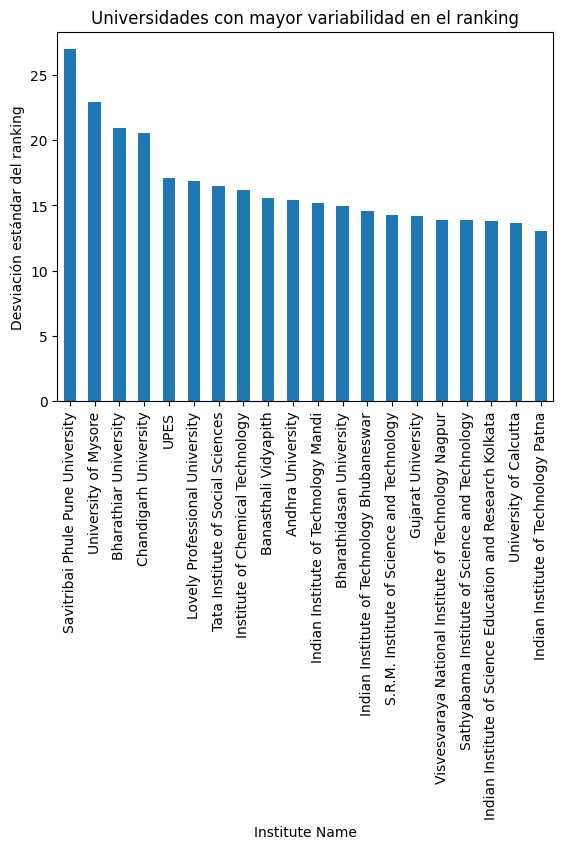

In [74]:
## Gráfico de universidades con mayor variabilidad:

rank_variability.sort_values(ascending=False).head(20).plot(kind="bar")
plt.title("Universidades con mayor variabilidad en el ranking")
plt.ylabel("Desviación estándar del ranking")
plt.show()

In [75]:
## Universidades en el Top 10:
top10 = df_Rank_final[df_Rank_final["Rank"] <= 10]
top10["Institute Name"].value_counts()


Institute Name
Indian Institute of Technology Madras            6
Indian Institute of Science                      6
Indian Institute of Technology Bombay            6
Indian Institute of Technology Delhi             6
Indian Institute of Technology Kanpur            6
Indian Institute of Technology Kharagpur         6
Indian Institute of Technology Roorkee           6
Jawaharlal Nehru University                      6
Indian Institute of Technology Guwahati          5
All India Institute of Medical Sciences Delhi    4
Banaras Hindu University                         3
Name: count, dtype: int64

Estas 8 primeras universidades se han mantenido en el Top 10 todos los años.

In [76]:
## variable Rank:

df_Rank_final.groupby("Año")["Rank"].describe()

,count,mean,std,min,25%,50%,75%,max
Año,,,,,,,,
2020,100.0,50.46,28.994399,1.0,25.75,50.5,75.25,100.0
2021,100.0,50.46,28.994399,1.0,25.75,50.5,75.25,100.0
2022,100.0,50.46,28.997882,1.0,25.75,50.5,75.25,100.0
2023,100.0,50.47,28.994411,1.0,25.75,50.5,75.25,100.0
2024,100.0,50.49,29.006615,1.0,25.75,50.5,75.25,100.0
2025,100.0,50.48,29.014618,1.0,25.75,50.5,75.25,100.0


In [67]:
## Qué estados tienen las mejores universidades del Top 100.
## Para esto, calculo el Score medio por Estado (de todas las universidades) y cuento el total de veces que aparecen en el df.
## Porque una cosa es que aparezca en el Top 100 pero no quiere decir que sea buena.
## Con esto, sé los Estados con mejores universidades. Que una universidad aparezca muchas veces no quiere decir que sea la mejor.

In [77]:
df_Rank_final.groupby("State")["Score"].agg(['mean', 'count']).sort_values("mean", ascending=False).round(2)

,mean,count
State,,
Delhi,61.90,43
Karnataka,58.11,36
Uttarakhand,58.10,16
West Bengal,56.90,37
Uttar Pradesh,56.64,49
Telangana,55.52,25
Jharkhand,55.13,6
Tamil Nadu,53.98,109
Assam,53.87,20


Un estado puede tener muchas universidades en el Top-100 pero con Score medio-bajo (como Tamil Nadu, que tiene volumen pero no necesariamente las mejores)
Otro puede tener pocas universidades pero con Score muy alto (como Delhi, que tiene institutos o universidades de élite como los IIT).

Volumen y calidad no van de la mano. El estado que más universidades aporta al Top-100 no es el que tiene mejores universidades. El Estado de Delhi gana en calidad, Tamil Nadu gana en cantidad.

In [78]:
## variable Score:

df_Rank_final.groupby("Año")["Score"].describe()

,count,mean,std,min,25%,50%,75%,max
Año,,,,,,,,
2020,100.0,51.1514,9.813370,41.10,44.7675,48.120,54.0150,86.76
2021,100.0,51.1514,9.813370,41.10,44.7675,48.120,54.0150,86.76
2022,100.0,53.6463,9.515247,44.35,46.9400,49.930,56.9300,87.59
2023,100.0,55.1119,8.984512,45.65,48.8250,51.910,58.4525,86.69
2024,100.0,56.7559,8.462508,47.43,51.0925,54.005,60.3250,86.42
2025,100.0,57.7612,8.175946,49.04,51.9825,55.350,60.4925,87.31


La media del Score va creciendo a lo largo del tiempo. Pasa de 51.2 a 57.8 puntos en cinco años, al igual que la mediana. Esto significa que
la mejora no se debe a valores extremos.

Las estadísticas de 2020 son idénticas a 2021. Ver qué pasa. Lo más probable es que sean dos ficheros idénticos. 

La dispersión va cayendo año tras año. Lo que sugiere una menor dispersión. 

En términos generales, el Score alcanza mejores resultados año tras año.

In [79]:
# Veo qué ocurre con los ficheros del 2020 y 2021. No habia duplicados en los 6 ficheros (2020-2025) pero ahora me doy cuenta que
# no había duplicados por la variable "Año".

# Comparo si los datos de 2020 y 2021 son idénticos (ignorando "Año")
df_2020 = df_Rank_final[df_Rank_final['Año'] == 2020].drop(columns='Año').reset_index(drop=True)
df_2021 = df_Rank_final[df_Rank_final['Año'] == 2021].drop(columns='Año').reset_index(drop=True)

print(df_2020.equals(df_2021))  # True = ficheros idénticos

True


In [80]:
# Veo que los valores del 2020 y 2021 son idénticos. 
# Compruebo si son identicos en las variables numéricas de indicadores, que entiendo que sí
df_2020 = df_Rank_final[df_Rank_final["Año"] == 2020].reset_index(drop=True)
df_2021 = df_Rank_final[df_Rank_final["Año"] == 2021].reset_index(drop=True)

cols = ['TLR','RPC','GO','OI','PERCEPTION','Score']
df_2020[cols].equals(df_2021[cols])  # True si son idénticos

True

Por tanto, se decide eliminar el año 2020 porque sus datos son idénticos a los de 2021.
Esto sugiere un error en la fuente original de los datos. El análisis se realizará con 5 años (2021-2025).

Se eliminará el año 2020 en la fase de Limpieza.

In [80]:
df_Rank_final.to_csv('../data/raw/df_Rank_final.csv',index=False)

In [73]:
############# FIN DE ANALISIS PRELIMINAR #################